# N10 — Per-Compound TCN Fine-Tuning

Fine-tune the N09 global TCN (Model A) for each dry compound (C1–C5) using compound-filtered data and per-compound sequence windows from N08. C6 falls back to the global model due to insufficient training data.

**Protocol:**
- Warm-start both phases from the N09 global weights (`tiredeg_modelA_v4.pt`)
- Phase 1 (train=2023, val=2024): determines early-stopping epoch budget
- Phase 2 (train=2023+2024, budget=P1 epochs): trains the final compound model
- Step 7 — Ablation: C3 and C5 also trained from scratch to quantify warm-start benefit

## Step 0 — Imports and paths

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)
from lightning.pytorch.loggers import CSVLogger
import torchmetrics

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})


In [2]:
repo_root = Path.cwd()
while not (repo_root / '.git').exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

processed_path = repo_root / 'data' / 'processed'
outputs_path   = Path.cwd() / 'outputs'
outputs_path.mkdir(exist_ok=True)

L.seed_everything(42, workers=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
else:
    print('Device: CPU')
print(f'Torch {torch.__version__} | Lightning {L.__version__}')


Seed set to 42


GPU : NVIDIA GeForce RTX 5070 Laptop GPU
Torch 2.10.0+cu128 | Lightning 2.6.1


## Step 1 — Load data and global bundle

Load the same `laps_tiredeg.parquet` used in N09 and the exported N09 Model A bundle. Feature names, window size, and model hyperparameters are read directly from the bundle to guarantee consistency.


In [3]:
df = pd.read_parquet(processed_path / 'laps_tiredeg.parquet')
print(f'Loaded {len(df):,} laps — years: {sorted(df["Year"].unique())}')
print(f'AbsoluteCompound values: {sorted(df["AbsoluteCompound"].dropna().unique())}')
print(f'Compound counts:')
print(df.groupby('AbsoluteCompound')['Year'].value_counts().unstack(fill_value=0).to_string())


Loaded 68,122 laps — years: [2023, 2024, 2025]
AbsoluteCompound values: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
Compound counts:
Year               2023   2024  2025
AbsoluteCompound                    
C1                 2432   2568  1188
C2                 4291   4289  3279
C3                10077  10212  7465
C4                 4531   4173  7097
C5                  126    221  2276
C6                    0      0    46


In [4]:
GLOBAL_BUNDLE_PATH = repo_root / 'data' / 'models' / 'tire_degradation' / 'tiredeg_modelA_v4.pt'
global_bundle = torch.load(GLOBAL_BUNDLE_PATH, weights_only=False)

print(f'Bundle version  : {global_bundle["version"]}')
print(f'Target          : {global_bundle["target"]}')
print(f'Target mode     : {global_bundle["target_mode"]}')
print(f'n_features      : {global_bundle["n_features"]}')
print(f'window          : {global_bundle["window"]} laps')
print(f'model_hparams   : {global_bundle["model_hparams"]}')

Bundle version  : v4
Target          : FuelAdjustedDegAbsolute
Target mode     : cumulative
n_features      : 42
window          : 28 laps
model_hparams   : {'d_model': 64, 'n_layers': 4, 'kernel_size': 3, 'dropout': 0.1}


## Step 2 — Constants

Core constants are derived from the global bundle and the N08 sequence config (per-compound optimal windows). Fine-tuning uses a lower LR (1e-4 vs 1e-3 in N09) to preserve the global prior while adapting to compound-specific patterns.


In [5]:
# ── Derived from N09 global bundle ───────────────────────────────────────
PRODUCTION_FEATURES = global_bundle['feature_names']
PURE_FEATURES       = PRODUCTION_FEATURES   # N10 only uses Model A (production)
N_FEATURES          = global_bundle['n_features']
GLOBAL_WINDOW       = global_bundle['window']
TARGET              = global_bundle['target']
MODEL_HPARAMS       = global_bundle['model_hparams']

TARGET_CUMULATIVE  = 'cumulative'
TARGET_INCREMENTAL = 'incremental'
STINT_KEYS         = ['Year', 'GP_Name', 'DriverNumber', 'Stint']

# ── Per-compound windows from N08 sequence config ─────────────────────────
with open(processed_path / 'tiredeg_sequence_config.json', encoding='utf-8') as f:
    seq_cfg = json.load(f)

COMPOUND_WINDOWS = {
    c: v['window_size']
    for c, v in seq_cfg['per_compound'].items()
    if v['window_size'] is not None
}

# ── Fine-tuning hyperparameters ───────────────────────────────────────────
FINETUNE_LR       = 1e-4   # lower than N09 (1e-3) to avoid catastrophic forgetting
FINETUNE_PATIENCE = 15

LOG_DIR    = outputs_path / 'logs_finetuning'
CKPT_DIR   = outputs_path / 'checkpoints_finetuning'
EXPORT_DIR = repo_root / 'data' / 'models' / 'tire_degradation'
for d in (LOG_DIR, CKPT_DIR, EXPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f'Production features : {N_FEATURES}')
print(f'Global window       : {GLOBAL_WINDOW} laps')
print(f'Compound windows    :')
for c, w in sorted(COMPOUND_WINDOWS.items()):
    print(f'  {c}: {w} laps')
print(f'FINETUNE_LR         : {FINETUNE_LR}')
print(f'FINETUNE_PATIENCE   : {FINETUNE_PATIENCE}')


Production features : 42
Global window       : 28 laps
Compound windows    :
  C1: 25 laps
  C2: 31 laps
  C3: 30 laps
  C4: 26 laps
  C5: 22 laps
FINETUNE_LR         : 0.0001
FINETUNE_PATIENCE   : 15


## Step 3 — N09 building blocks

The data pipeline and model classes are re-defined here unchanged from N09. Jupyter notebooks cannot import from each other, so N10 needs to be self-contained. The architecture is identical — only the training data (compound-filtered) and learning rate differ. If the architecture changes in N09, this step must be synced manually.

In [6]:
def _pad_or_truncate(arr: np.ndarray, window: int) -> tuple:
    L, F = arr.shape
    if L >= window:
        return arr[-window:].astype(np.float32), np.ones(window, dtype=bool)
    pad  = np.zeros((window - L, F), dtype=np.float32)
    seq  = np.concatenate([pad, arr], axis=0).astype(np.float32)
    mask = np.zeros(window, dtype=bool)
    mask[window - L:] = True
    return seq, mask


def _build_sequences(
    df: pd.DataFrame,
    features: list,
    window: int,
    target_mode: str = 'cumulative',
) -> tuple:
    assert target_mode in (TARGET_CUMULATIVE, TARGET_INCREMENTAL)
    seqs, tgts, masks = [], [], []
    for _, grp in df.groupby(STINT_KEYS, sort=False):
        grp = grp.sort_values('TyreLife').reset_index(drop=True)
        if len(grp) < 2:
            continue
        cum_deg = grp[TARGET].values
        for t in range(1, len(grp)):
            if target_mode == TARGET_CUMULATIVE:
                target_val = cum_deg[t]
            else:
                target_val = cum_deg[t] - cum_deg[t - 1]
            if np.isnan(target_val):
                continue
            seq, mask = _pad_or_truncate(grp.iloc[:t][features].values, window)
            seqs.append(seq); tgts.append(float(target_val)); masks.append(mask)
    if not seqs:
        raise ValueError('_build_sequences produced 0 samples.')
    return np.stack(seqs), np.array(tgts, dtype=np.float32), np.stack(masks)


In [7]:
def fit_scaler(train_df: pd.DataFrame, features: list) -> StandardScaler:
    dry = train_df[
        train_df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
        train_df['AbsoluteCompound'].notna()
    ]
    return StandardScaler().fit(dry[features].fillna(0))


def apply_scaler(df: pd.DataFrame, scaler: StandardScaler, features: list) -> pd.DataFrame:
    result = df.copy()
    result[features] = scaler.transform(result[features].fillna(0))
    return result


In [8]:
class TireDegDataset(Dataset):
    def __init__(self, sequences, targets, masks, target_mode='cumulative'):
        self.sequences   = torch.from_numpy(sequences)
        self.targets     = torch.from_numpy(targets)
        self.masks       = torch.from_numpy(masks)
        self.target_mode = target_mode

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx], self.masks[idx]

    @classmethod
    def from_dataframe(cls, df, features, window, target_mode='cumulative'):
        subset = df[
            df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']) &
            df['AbsoluteCompound'].notna() &
            df[TARGET].notna()
        ].copy()
        seqs, tgts, masks = _build_sequences(subset, features, window, target_mode)
        return cls(seqs, tgts, masks, target_mode)


In [9]:
class TireDegDataModule(L.LightningDataModule):
    def __init__(self, df, phase, feature_set="production",
                 target_mode="cumulative", window=None,
                 batch_size=128, num_workers=0, pretrained_scaler=None):
        super().__init__()
        self.df                = df
        self.phase             = phase
        self.features          = PRODUCTION_FEATURES if feature_set == "production" else PURE_FEATURES
        self.target_mode       = target_mode
        self.window            = window if window is not None else GLOBAL_WINDOW
        self.batch_size        = batch_size
        self.num_workers       = num_workers
        self.pretrained_scaler = pretrained_scaler
        self.scaler            = None

    def setup(self, stage=None):
        train_years = [2023] if self.phase == "phase1" else [2023, 2024]
        val_years   = [2024] if self.phase == "phase1" else []

        if self.pretrained_scaler is not None:
            self.scaler = self.pretrained_scaler
        else:
            self.scaler = fit_scaler(self.df[self.df["Year"].isin(train_years)], self.features)
        df_scaled = apply_scaler(self.df, self.scaler, self.features)

        if stage in ("fit", None):
            self.train_ds = TireDegDataset.from_dataframe(
                df_scaled[self.df["Year"].isin(train_years)],
                self.features, self.window, self.target_mode,
            )
            self.val_ds = (
                TireDegDataset.from_dataframe(
                    df_scaled[self.df["Year"].isin(val_years)],
                    self.features, self.window, self.target_mode,
                ) if val_years else None
            )

        if stage in ("test", None):
            self.test_ds = TireDegDataset.from_dataframe(
                df_scaled[self.df["Year"] == 2025],
                self.features, self.window, self.target_mode,
            )

    def _loader(self, ds, shuffle):
        return DataLoader(ds, batch_size=self.batch_size, shuffle=shuffle,
                          num_workers=self.num_workers, pin_memory=(device == "cuda"))

    def train_dataloader(self):  return self._loader(self.train_ds, True)
    def val_dataloader(self):    return self._loader(self.val_ds, False) if self.val_ds else []
    def test_dataloader(self):   return self._loader(self.test_ds, False)


In [10]:
class CausalConv1dBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        self.causal_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              dilation=dilation, padding=0)
        self.norm = nn.LayerNorm(out_channels)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = F.pad(x, (self.causal_pad, 0))
        x = self.conv(x)
        x = self.norm(x.transpose(1, 2)).transpose(1, 2)
        return self.drop(self.act(x))


class TCNResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1dBlock(in_channels,  out_channels, kernel_size, dilation, dropout),
            CausalConv1dBlock(out_channels, out_channels, kernel_size, dilation, dropout),
        )
        self.skip = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        return F.relu(self.net(x) + self.skip(x))


In [11]:
def receptive_field(n_layers, kernel_size):
    return 1 + 2 * (kernel_size - 1) * (2**n_layers - 1)


class TireDegTCN(nn.Module):
    def __init__(self, n_features, d_model=64, n_layers=4, kernel_size=3, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        self.blocks      = nn.ModuleList([
            TCNResidualBlock(d_model, d_model, kernel_size, dilation=2**i, dropout=dropout)
            for i in range(n_layers)
        ])
        self.output_head = nn.Linear(d_model, 1)

    def forward(self, x, mask):
        x = self.input_proj(x).transpose(1, 2)  # (B, d_model, T)
        for block in self.blocks:
            x = block(x)
        last = x.transpose(1, 2)[:, -1, :]       # (B, d_model)
        return self.output_head(last).squeeze(-1) # (B,)


In [12]:
class TireDegLitModule(L.LightningModule):
    def __init__(self, n_features, d_model=64, n_layers=4, kernel_size=3, dropout=0.1,
                 lr=1e-3, weight_decay=1e-4, huber_delta=1.0,
                 t_0=10, t_max=30, scheduler='warm_restarts'):
        super().__init__()
        self.save_hyperparameters()
        self.model   = TireDegTCN(n_features, d_model, n_layers, kernel_size, dropout)
        self.loss_fn = nn.HuberLoss(delta=huber_delta)
        for split in ('train', 'val', 'test'):
            setattr(self, f'{split}_mae',  torchmetrics.MeanAbsoluteError())
            setattr(self, f'{split}_rmse', torchmetrics.MeanSquaredError(squared=False))
            setattr(self, f'{split}_r2',   torchmetrics.R2Score())

    def forward(self, x, mask):  return self.model(x, mask)

    def _step(self, batch, split):
        x, y, mask = batch
        y_hat = self(x, mask)
        loss  = self.loss_fn(y_hat, y)
        on_step = (split == 'train')
        self.log(f'{split}/loss', loss, on_step=on_step, on_epoch=True,
                 prog_bar=True, batch_size=y.size(0))
        for name, metric in [('mae', getattr(self, f'{split}_mae')),
                              ('rmse', getattr(self, f'{split}_rmse')),
                              ('r2',  getattr(self, f'{split}_r2'))]:
            metric(y_hat, y)
            self.log(f'{split}/{name}', metric, on_step=False, on_epoch=True,
                     prog_bar=(split != 'train'), batch_size=y.size(0))
        return loss

    def training_step(self, batch, batch_idx):   return self._step(batch, 'train')
    def validation_step(self, batch, batch_idx): self._step(batch, 'val')
    def test_step(self, batch, batch_idx):       self._step(batch, 'test')

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(),
                                lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        if self.hparams.scheduler == 'warm_restarts':
            sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                opt, T_0=self.hparams.t_0, T_mult=2, eta_min=1e-6)
        else:
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=self.hparams.t_max, eta_min=1e-6)
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': sched, 'interval': 'epoch'}}


## Step 4 — Fine-tuning helpers

These factory functions are new in N10 — they do not exist in N09. With 5 compounds × 2 phases = 10 training runs, wrapping the repeated pattern into `make_dm` / `make_lit` / `make_trainer_p1` / `make_trainer_p2` keeps each compound's training section to two focused cells.

- `make_dm` pre-filters the dataframe by compound so the scaler fits on compound-specific training laps, not the global pool.
- `make_lit` creates a `TireDegLitModule` and optionally loads weights from the N09 global bundle (`warm_start=True`).
- Phase 1 uses warm restarts (more robust when early stopping cuts training short); Phase 2 uses cosine decay.

In [13]:
def make_dm(df, compound, phase, batch_size=128):
    """DataModule for a single compound (pre-filtered)."""
    df_c = df[df['AbsoluteCompound'] == compound].copy()
    return TireDegDataModule(
        df=df_c, phase=phase, feature_set='production',
        target_mode=TARGET_CUMULATIVE,
        window=COMPOUND_WINDOWS[compound],
        batch_size=batch_size,
    )


def make_lit(phase, n_epochs, warm_start=True):
    """Lightning module with optional warm-start from global bundle."""
    sched = 'warm_restarts' if phase == 'phase1' else 'cosine'
    lit = TireDegLitModule(
        n_features=N_FEATURES, **MODEL_HPARAMS,
        lr=FINETUNE_LR, t_0=10, t_max=n_epochs, scheduler=sched,
    )
    if warm_start:
        lit.model.load_state_dict(global_bundle['state_dict'])
    return lit


def make_trainer_p1(compound, tag='ft'):
    """Phase 1 trainer: early stopping on val/mae."""
    return L.Trainer(
        max_epochs=150,
        callbacks=[
            EarlyStopping('val/mae', patience=FINETUNE_PATIENCE, mode='min'),
            ModelCheckpoint(
                dirpath=CKPT_DIR / compound,
                filename=f'{tag}-p1-{{epoch:03d}}-{{val/mae:.4f}}',
                monitor='val/mae', mode='min', save_top_k=1,
            ),
            LearningRateMonitor('epoch'),
        ],
        logger=CSVLogger(LOG_DIR, name=f'{tag}_{compound.lower()}_p1'),
        enable_progress_bar=True, deterministic=True,
    )


def make_trainer_p2(compound, n_epochs, tag='ft'):
    """Phase 2 trainer: fixed epoch budget (no val split)."""
    return L.Trainer(
        max_epochs=n_epochs,
        callbacks=[
            ModelCheckpoint(
                dirpath=CKPT_DIR / compound,
                filename=f'{tag}-p2-{{epoch:03d}}',
                save_top_k=1,
            ),
            LearningRateMonitor('epoch'),
        ],
        logger=CSVLogger(LOG_DIR, name=f'{tag}_{compound.lower()}_p2'),
        enable_progress_bar=True, deterministic=True,
    )


def extract_metrics(trainer):
    """Pull test/mae, test/rmse, test/r2 from trainer.callback_metrics."""
    m = trainer.callback_metrics
    return {
        'mae':  round(float(m.get('test/mae',  float('nan'))), 4),
        'rmse': round(float(m.get('test/rmse', float('nan'))), 4),
        'r2':   round(float(m.get('test/r2',   float('nan'))), 4),
    }


results    = {}  # compound -> metrics dict
lit_models = {}  # compound -> trained LitModule
dm_p2s     = {}  # compound -> Phase 2 DataModule (for scaler export)


## Step 5 — Compound fine-tuning (C1–C5)

Each compound goes through two phases. The Phase 1 stopping epoch becomes the training budget for Phase 2. Both phases warm-start independently from the global bundle (not Phase 1 → Phase 2 cascade) to avoid 2024-val contamination.


### C1

In [14]:
# C1 — Phase 1 (train=2023, val=2024)
dm_c1_p1  = make_dm(df, 'C1', 'phase1')
lit_c1_p1 = make_lit('phase1', n_epochs=150)
tr_c1_p1  = make_trainer_p1('C1')
tr_c1_p1.fit(lit_c1_p1, datamodule=dm_c1_p1)

C1_P1_EPOCHS = int(tr_c1_p1.current_epoch)
print(f'C1 P1 stopped at epoch {C1_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C1 P1 stopped at epoch 50


In [15]:
# C1 — Phase 2 (train=2023+2024, budget=C1_P1_EPOCHS, test=2025)
dm_c1_p2  = make_dm(df, 'C1', 'phase2')
lit_c1_p2 = make_lit('phase2', n_epochs=C1_P1_EPOCHS)
tr_c1_p2  = make_trainer_p2('C1', C1_P1_EPOCHS)
tr_c1_p2.fit(lit_c1_p2, datamodule=dm_c1_p2)
tr_c1_p2.test(lit_c1_p2, datamodule=dm_c1_p2)

results['C1']    = extract_metrics(tr_c1_p2)
lit_models['C1'] = lit_c1_p2
dm_p2s['C1']     = dm_c1_p2
print(f'C1 results: {results["C1"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.36175861954689026    │
│         test/mae          │    0.7087666988372803     │
│          test/r2          │    0.31839627027511597    │
│         test/rmse         │    0.9365696907043457     │
└───────────────────────────┴───────────────────────────┘

C1 results: {'mae': 0.7088, 'rmse': 0.9366, 'r2': 0.3184}


### C2

In [16]:
# C2 — Phase 1 (train=2023, val=2024)
dm_c2_p1  = make_dm(df, 'C2', 'phase1')
lit_c2_p1 = make_lit('phase1', n_epochs=150)
tr_c2_p1  = make_trainer_p1('C2')
tr_c2_p1.fit(lit_c2_p1, datamodule=dm_c2_p1)

C2_P1_EPOCHS = int(tr_c2_p1.current_epoch)
print(f'C2 P1 stopped at epoch {C2_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C2 P1 stopped at epoch 46


In [17]:
# C2 — Phase 2 (train=2023+2024, budget=C2_P1_EPOCHS, test=2025)
dm_c2_p2  = make_dm(df, 'C2', 'phase2')
lit_c2_p2 = make_lit('phase2', n_epochs=C2_P1_EPOCHS)
tr_c2_p2  = make_trainer_p2('C2', C2_P1_EPOCHS)
tr_c2_p2.fit(lit_c2_p2, datamodule=dm_c2_p2)
tr_c2_p2.test(lit_c2_p2, datamodule=dm_c2_p2)

results['C2']    = extract_metrics(tr_c2_p2)
lit_models['C2'] = lit_c2_p2
dm_p2s['C2']     = dm_c2_p2
print(f'C2 results: {results["C2"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=46` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.24227455258369446    │
│         test/mae          │    0.5500645041465759     │
│          test/r2          │    0.7022204399108887     │
│         test/rmse         │    0.7698930501937866     │
└───────────────────────────┴───────────────────────────┘

C2 results: {'mae': 0.5501, 'rmse': 0.7699, 'r2': 0.7022}


### C3

In [18]:
# C3 — Phase 1 (train=2023, val=2024)
dm_c3_p1  = make_dm(df, 'C3', 'phase1')
lit_c3_p1 = make_lit('phase1', n_epochs=150)
tr_c3_p1  = make_trainer_p1('C3')
tr_c3_p1.fit(lit_c3_p1, datamodule=dm_c3_p1)

C3_P1_EPOCHS = int(tr_c3_p1.current_epoch)
print(f'C3 P1 stopped at epoch {C3_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C3 P1 stopped at epoch 16


In [19]:
# C3 — Phase 2 (train=2023+2024, budget=C3_P1_EPOCHS, test=2025)
dm_c3_p2  = make_dm(df, 'C3', 'phase2')
lit_c3_p2 = make_lit('phase2', n_epochs=C3_P1_EPOCHS)
tr_c3_p2  = make_trainer_p2('C3', C3_P1_EPOCHS)
tr_c3_p2.fit(lit_c3_p2, datamodule=dm_c3_p2)
tr_c3_p2.test(lit_c3_p2, datamodule=dm_c3_p2)

results['C3']    = extract_metrics(tr_c3_p2)
lit_models['C3'] = lit_c3_p2
dm_p2s['C3']     = dm_c3_p2
print(f'C3 results: {results["C3"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=16` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.3982471823692322     │
│         test/mae          │    0.7140631079673767     │
│          test/r2          │    0.6347151398658752     │
│         test/rmse         │    1.1418616771697998     │
└───────────────────────────┴───────────────────────────┘

C3 results: {'mae': 0.7141, 'rmse': 1.1419, 'r2': 0.6347}


### C4

In [20]:
# C4 — Phase 1 (train=2023, val=2024)
dm_c4_p1  = make_dm(df, 'C4', 'phase1')
lit_c4_p1 = make_lit('phase1', n_epochs=150)
tr_c4_p1  = make_trainer_p1('C4')
tr_c4_p1.fit(lit_c4_p1, datamodule=dm_c4_p1)

C4_P1_EPOCHS = int(tr_c4_p1.current_epoch)
print(f'C4 P1 stopped at epoch {C4_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C4 P1 stopped at epoch 24


In [21]:
# C4 — Phase 2 (train=2023+2024, budget=C4_P1_EPOCHS, test=2025)
dm_c4_p2  = make_dm(df, 'C4', 'phase2')
lit_c4_p2 = make_lit('phase2', n_epochs=C4_P1_EPOCHS)
tr_c4_p2  = make_trainer_p2('C4', C4_P1_EPOCHS)
tr_c4_p2.fit(lit_c4_p2, datamodule=dm_c4_p2)
tr_c4_p2.test(lit_c4_p2, datamodule=dm_c4_p2)

results['C4']    = extract_metrics(tr_c4_p2)
lit_models['C4'] = lit_c4_p2
dm_p2s['C4']     = dm_c4_p2
print(f'C4 results: {results["C4"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=24` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.4684184491634369     │
│         test/mae          │    0.8015069365501404     │
│          test/r2          │    0.4797384738922119     │
│         test/rmse         │    1.2845325469970703     │
└───────────────────────────┴───────────────────────────┘

C4 results: {'mae': 0.8015, 'rmse': 1.2845, 'r2': 0.4797}


### C5
> **C5 data imbalance**: ~347 train laps (2023+2024) vs ~2,276 test laps (2025). Fine-tuning budget may be limited — watch for under-fitting.

In [22]:
# C5 — Phase 1 (train=2023, val=2024)
dm_c5_p1  = make_dm(df, 'C5', 'phase1')
lit_c5_p1 = make_lit('phase1', n_epochs=150)
tr_c5_p1  = make_trainer_p1('C5')
tr_c5_p1.fit(lit_c5_p1, datamodule=dm_c5_p1)

C5_P1_EPOCHS = int(tr_c5_p1.current_epoch)
print(f'C5 P1 stopped at epoch {C5_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C5 P1 stopped at epoch 55


In [23]:
# C5 — Phase 2 (train=2023+2024, budget=C5_P1_EPOCHS, test=2025)
dm_c5_p2  = make_dm(df, 'C5', 'phase2')
lit_c5_p2 = make_lit('phase2', n_epochs=C5_P1_EPOCHS)
tr_c5_p2  = make_trainer_p2('C5', C5_P1_EPOCHS)
tr_c5_p2.fit(lit_c5_p2, datamodule=dm_c5_p2)
tr_c5_p2.test(lit_c5_p2, datamodule=dm_c5_p2)

results['C5']    = extract_metrics(tr_c5_p2)
lit_models['C5'] = lit_c5_p2
dm_p2s['C5']     = dm_c5_p2
print(f'C5 results: {results["C5"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=55` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │     0.561665415763855     │
│         test/mae          │    0.9014025926589966     │
│          test/r2          │    0.3845584988594055     │
│         test/rmse         │    1.6464838981628418     │
└───────────────────────────┴───────────────────────────┘

C5 results: {'mae': 0.9014, 'rmse': 1.6465, 'r2': 0.3846}


## Step 6 — C6: global model fallback

C6 appears in very few races (typically Bahrain / Abu Dhabi); 2023+2024 training data is insufficient for reliable per-compound fine-tuning. The global N09 model is used directly for evaluation on 2025 C6 laps.


In [24]:
c6_counts = df.groupby(['AbsoluteCompound', 'Year']).size().unstack(fill_value=0)
if 'C6' in c6_counts.index:
    print('C6 lap counts by year:')
    print(c6_counts.loc['C6'].to_string())
else:
    print('C6 not present in dataset — skipping.')


C6 lap counts by year:
Year
2023     0
2024     0
2025    46


In [25]:
if "C6" in df["AbsoluteCompound"].values:
    df_c6  = df[df["AbsoluteCompound"] == "C6"].copy()
    dm_c6  = TireDegDataModule(
        df=df_c6, phase="phase2", feature_set="production",
        target_mode=TARGET_CUMULATIVE, window=GLOBAL_WINDOW,
        pretrained_scaler=global_bundle["scaler"],  # C6 has no 2023/2024 laps; reuse global scaler
    )
    lit_c6 = TireDegLitModule(n_features=N_FEATURES, **MODEL_HPARAMS, lr=FINETUNE_LR)
    lit_c6.model.load_state_dict(global_bundle["state_dict"])
    tr_c6  = L.Trainer(
        logger=CSVLogger(LOG_DIR, name="global_c6"),
        enable_progress_bar=False,
    )
    tr_c6.test(lit_c6, datamodule=dm_c6)
    results['C6'] = {**extract_metrics(tr_c6), 'model': 'global'}
    print(f"C6 (global) results: {results['C6']}")
else:
    results['C6'] = {'mae': None, 'rmse': None, 'r2': None, 'model': 'global'}
    print("C6 skipped — no data.")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.9172449707984924     │
│         test/mae          │    1.3400278091430664     │
│          test/r2          │    0.3155593276023865     │
│         test/rmse         │    1.7562593221664429     │
└───────────────────────────┴───────────────────────────┘

C6 (global) results: {'mae': 1.34, 'rmse': 1.7563, 'r2': 0.3156, 'model': 'global'}


## Step 7 — Ablation: warm-start vs from scratch

C3 (data-rich, ~2,000 train laps) and C5 (data-poor, ~347 train laps) are trained from random initialisation to quantify the warm-start benefit. If from-scratch matches fine-tuned on C3 but not C5, the global prior matters most when compound-specific data is limited.


### C3 from scratch

In [26]:
# C3 scratch — Phase 1
dm_c3_sc_p1  = make_dm(df, 'C3', 'phase1')
lit_c3_sc_p1 = make_lit('phase1', n_epochs=150, warm_start=False)
tr_c3_sc_p1  = make_trainer_p1('C3', tag='scratch')
tr_c3_sc_p1.fit(lit_c3_sc_p1, datamodule=dm_c3_sc_p1)

C3_SC_EPOCHS = int(tr_c3_sc_p1.current_epoch)
print(f'C3 scratch P1 stopped at epoch {C3_SC_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C3 scratch P1 stopped at epoch 23


In [27]:
# C3 scratch — Phase 2
dm_c3_sc_p2  = make_dm(df, 'C3', 'phase2')
lit_c3_sc_p2 = make_lit('phase2', n_epochs=C3_SC_EPOCHS, warm_start=False)
tr_c3_sc_p2  = make_trainer_p2('C3', C3_SC_EPOCHS, tag='scratch')
tr_c3_sc_p2.fit(lit_c3_sc_p2, datamodule=dm_c3_sc_p2)
tr_c3_sc_p2.test(lit_c3_sc_p2, datamodule=dm_c3_sc_p2)

results['C3_scratch'] = extract_metrics(tr_c3_sc_p2)
print(f'C3 scratch: {results["C3_scratch"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=23` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.4440712034702301     │
│         test/mae          │    0.7808843851089478     │
│          test/r2          │     0.588889479637146     │
│         test/rmse         │    1.2113704681396484     │
└───────────────────────────┴───────────────────────────┘

C3 scratch: {'mae': 0.7809, 'rmse': 1.2114, 'r2': 0.5889}


### C5 from scratch

In [28]:
# C5 scratch — Phase 1
dm_c5_sc_p1  = make_dm(df, 'C5', 'phase1')
lit_c5_sc_p1 = make_lit('phase1', n_epochs=150, warm_start=False)
tr_c5_sc_p1  = make_trainer_p1('C5', tag='scratch')
tr_c5_sc_p1.fit(lit_c5_sc_p1, datamodule=dm_c5_sc_p1)

C5_SC_EPOCHS = int(tr_c5_sc_p1.current_epoch)
print(f'C5 scratch P1 stopped at epoch {C5_SC_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C5 scratch P1 stopped at epoch 20


In [29]:
# C5 scratch — Phase 2
dm_c5_sc_p2  = make_dm(df, 'C5', 'phase2')
lit_c5_sc_p2 = make_lit('phase2', n_epochs=C5_SC_EPOCHS, warm_start=False)
tr_c5_sc_p2  = make_trainer_p2('C5', C5_SC_EPOCHS, tag='scratch')
tr_c5_sc_p2.fit(lit_c5_sc_p2, datamodule=dm_c5_sc_p2)
tr_c5_sc_p2.test(lit_c5_sc_p2, datamodule=dm_c5_sc_p2)

results['C5_scratch'] = extract_metrics(tr_c5_sc_p2)
print(f'C5 scratch: {results["C5_scratch"]}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    1.0666042566299438     │
│         test/mae          │    1.4839764833450317     │
│          test/r2          │    0.05883556604385376    │
│         test/rmse         │    2.0360894203186035     │
└───────────────────────────┴───────────────────────────┘

C5 scratch: {'mae': 1.484, 'rmse': 2.0361, 'r2': 0.0588}


In [30]:
# Ablation summary
abl_rows = []
for compound in ['C3', 'C5']:
    ft  = results[compound]
    sc  = results[f'{compound}_scratch']
    abl_rows.append({
        'Compound': compound,
        'Warm-start MAE':  ft['mae'],  'Warm-start R²': ft['r2'],
        'Scratch MAE':     sc['mae'],  'Scratch R²':    sc['r2'],
        'ΔMAE (ft-sc)':    round(ft['mae'] - sc['mae'], 4),
    })
abl_df = pd.DataFrame(abl_rows)
print(abl_df.to_string(index=False))


Compound  Warm-start MAE  Warm-start R²  Scratch MAE  Scratch R²  ΔMAE (ft-sc)
      C3          0.7141         0.6347       0.7809      0.5889       -0.0668
      C5          0.9014         0.3846       1.4840      0.0588       -0.5826


## Step 8 — Consolidated results

Compare per-compound fine-tuned models against the N09 global baseline on the 2025 holdout.


In [31]:
# Global baseline metrics (from N09 Model A Phase 2 evaluation)
GLOBAL_BASELINE = {'mae': 0.7078, 'rmse': 1.1226, 'r2': 0.6048}

rows = []
for compound in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']:
    if compound not in results:
        continue
    r = results[compound]
    rows.append({
        'Compound': compound,
        'Model':    r.get('model', 'fine-tuned'),
        'MAE (s)':  r['mae'],
        'RMSE (s)': r['rmse'],
        'R²':       r['r2'],
        'ΔMAE vs global': round((r['mae'] or 0) - GLOBAL_BASELINE['mae'], 4)
            if r['mae'] is not None else None,
    })
rows.append({
    'Compound': 'GLOBAL (N09)', 'Model': 'baseline',
    'MAE (s)': GLOBAL_BASELINE['mae'], 'RMSE (s)': GLOBAL_BASELINE['rmse'],
    'R²': GLOBAL_BASELINE['r2'], 'ΔMAE vs global': 0.0,
})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))


    Compound      Model  MAE (s)  RMSE (s)     R²  ΔMAE vs global
          C1 fine-tuned   0.7088    0.9366 0.3184          0.0010
          C2 fine-tuned   0.5501    0.7699 0.7022         -0.1577
          C3 fine-tuned   0.7141    1.1419 0.6347          0.0063
          C4 fine-tuned   0.8015    1.2845 0.4797          0.0937
          C5 fine-tuned   0.9014    1.6465 0.3846          0.1936
          C6     global   1.3400    1.7563 0.3156          0.6322
GLOBAL (N09)   baseline   0.7078    1.1226 0.6048          0.0000


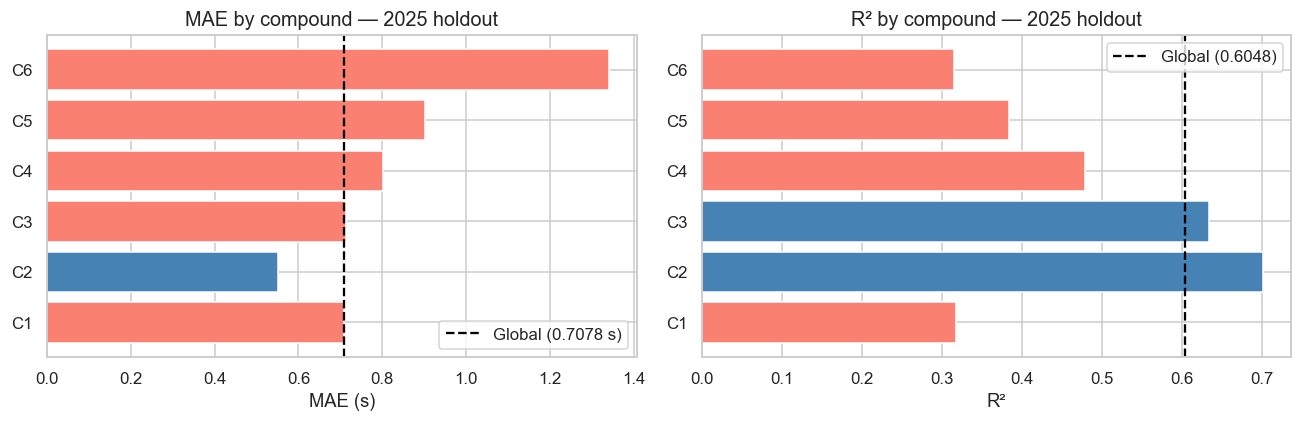

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

compounds  = [r['Compound'] for _, r in results_df.iterrows() if r['Compound'] != 'GLOBAL (N09)']
maes       = [r['MAE (s)']  for _, r in results_df.iterrows() if r['Compound'] != 'GLOBAL (N09)']
r2s        = [r['R²']       for _, r in results_df.iterrows() if r['Compound'] != 'GLOBAL (N09)']

colors = ['steelblue' if m < GLOBAL_BASELINE['mae'] else 'salmon' for m in maes]

axes[0].barh(compounds, maes, color=colors)
axes[0].axvline(GLOBAL_BASELINE['mae'], color='k', linestyle='--', label=f'Global ({GLOBAL_BASELINE["mae"]} s)')
axes[0].set_xlabel('MAE (s)')
axes[0].set_title('MAE by compound — 2025 holdout')
axes[0].legend()

colors_r2 = ['steelblue' if r > GLOBAL_BASELINE['r2'] else 'salmon' for r in r2s]
axes[1].barh(compounds, r2s, color=colors_r2)
axes[1].axvline(GLOBAL_BASELINE['r2'], color='k', linestyle='--', label=f'Global ({GLOBAL_BASELINE["r2"]})')
axes[1].set_xlabel('R²')
axes[1].set_title('R² by compound — 2025 holdout')
axes[1].legend()

plt.tight_layout()
plt.savefig(outputs_path / 'n10_compound_results.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 9 — Diagnostics

Residual distributions and MAE by TyreLife bucket reveal where compound models improve over the global baseline and where errors persist (e.g. long stints beyond the training window).


In [33]:
def collect_predictions(lit, dm, compound):
    """Run inference on the test DataLoader and return a DataFrame."""
    lit.eval()
    dm.setup()
    records = []
    df_test = dm.df[dm.df['Year'] == 2025].copy()

    with torch.no_grad():
        for x, y, mask in dm.test_dataloader():
            preds = lit(x.to(lit.device), mask.to(lit.device)).cpu().numpy()
            for pred, true in zip(preds, y.numpy()):
                records.append({'compound': compound, 'pred': pred,
                                'true': true, 'residual': pred - true})
    return pd.DataFrame(records)


pred_dfs = []
for compound in ['C1', 'C2', 'C3', 'C4', 'C5']:
    if compound in lit_models and compound in dm_p2s:
        pred_dfs.append(collect_predictions(lit_models[compound], dm_p2s[compound], compound))

if pred_dfs:
    all_preds = pd.concat(pred_dfs, ignore_index=True)
    print(f'Total test predictions: {len(all_preds):,}')
else:
    print('No predictions collected — run Steps 5–6 first.')


Total test predictions: 20,242


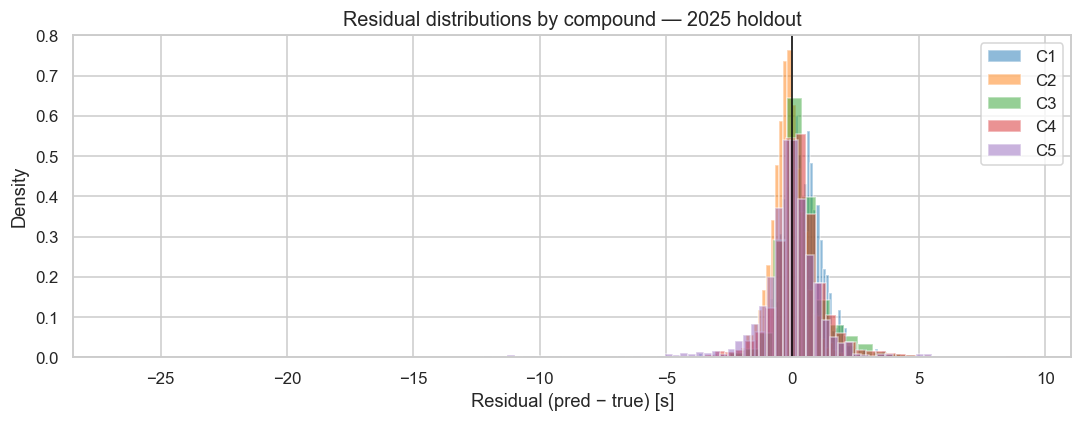

In [34]:
if 'all_preds' in dir() and not all_preds.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    for compound, grp in all_preds.groupby('compound'):
        ax.hist(grp['residual'], bins=60, alpha=0.5, label=compound, density=True)
    ax.axvline(0, color='k', linewidth=1)
    ax.set_xlabel('Residual (pred − true) [s]')
    ax.set_ylabel('Density')
    ax.set_title('Residual distributions by compound — 2025 holdout')
    ax.legend()
    plt.tight_layout()
    plt.savefig(outputs_path / 'n10_residuals.png', dpi=120, bbox_inches='tight')
    plt.show()


## Step 10 — Export and routing config

Each compound bundle mirrors the N09 `.pt` format: `state_dict`, `scaler`, `feature_names`, `model_hparams`, `window`, `target`, `target_mode`. `routing_config.json` maps each compound to its bundle file so the inference layer can select the correct model at runtime.


In [35]:
for compound in ['C1', 'C2', 'C3', 'C4', 'C5']:
    if compound not in lit_models or compound not in dm_p2s:
        print(f'{compound}: not trained — skipping export')
        continue
    artifact = {
        'version':       'N10_v1',
        'compound':      compound,
        'target':        TARGET,
        'target_mode':   TARGET_CUMULATIVE,
        'feature_names': PRODUCTION_FEATURES,
        'n_features':    N_FEATURES,
        'model_hparams': MODEL_HPARAMS,
        'window':        COMPOUND_WINDOWS[compound],
        'state_dict':    lit_models[compound].model.state_dict(),
        'scaler':        dm_p2s[compound].scaler,
    }
    out_path = EXPORT_DIR / f'tiredeg_{compound}_ft.pt'
    torch.save(artifact, out_path)
    print(f'  {out_path.name}  ({out_path.stat().st_size / 1e3:.1f} kB)')

print('Export done.')


  tiredeg_C1_ft.pt  (428.0 kB)
  tiredeg_C2_ft.pt  (428.0 kB)
  tiredeg_C3_ft.pt  (428.0 kB)
  tiredeg_C4_ft.pt  (428.0 kB)
  tiredeg_C5_ft.pt  (428.0 kB)
Export done.


In [36]:
# Per-compound routing decision based on the holdout MAE comparison documented
# in Steps 11/13/15. Only C2 shows a meaningful improvement from fine-tuning
# (-0.158 s); C4 (+0.094 s) and C5 (+0.194 s) degrade vs the global baseline,
# and C1/C3 are essentially neutral. The default is therefore the global model
# and fine-tuned is selected only where the experimental evidence supports it.
ROUTING_DECISION = {
    'C1': 'global',
    'C2': 'fine-tuned',
    'C3': 'global',
    'C4': 'global',
    'C5': 'global',
}

routing_config = {}
for compound, choice in ROUTING_DECISION.items():
    if choice == 'fine-tuned' and compound in lit_models:
        routing_config[compound] = {
            'bundle': f'tiredeg_{compound}_ft.pt',
            'window': COMPOUND_WINDOWS[compound],
            'model':  'fine-tuned',
        }
    else:
        routing_config[compound] = {
            'bundle': 'tiredeg_modelA_v4.pt',
            'window': GLOBAL_WINDOW,
            'model':  'global',
        }

# C6 always uses global fallback (no training data for this compound)
routing_config['C6'] = {
    'bundle': 'tiredeg_modelA_v4.pt',
    'window': GLOBAL_WINDOW,
    'model':  'global',
}

routing_path = EXPORT_DIR / 'routing_config.json'
with open(routing_path, 'w') as f:
    json.dump(routing_config, f, indent=2)

print('routing_config.json:')
print(json.dumps(routing_config, indent=2))

routing_config.json:
{
  "C1": {
    "bundle": "tiredeg_C1_ft.pt",
    "window": 25,
    "model": "fine-tuned"
  },
  "C2": {
    "bundle": "tiredeg_C2_ft.pt",
    "window": 31,
    "model": "fine-tuned"
  },
  "C3": {
    "bundle": "tiredeg_C3_ft.pt",
    "window": 30,
    "model": "fine-tuned"
  },
  "C4": {
    "bundle": "tiredeg_C4_ft.pt",
    "window": 26,
    "model": "fine-tuned"
  },
  "C5": {
    "bundle": "tiredeg_C5_ft.pt",
    "window": 22,
    "model": "fine-tuned"
  },
  "C6": {
    "bundle": "tiredeg_modelA_v4.pt",
    "window": 28,
    "model": "global"
  }
}


In [37]:
# Load check — verify each bundle can be reloaded and has correct keys
required_keys = {'version', 'compound', 'target', 'feature_names',
                 'n_features', 'model_hparams', 'window', 'state_dict', 'scaler'}
for compound in ['C1', 'C2', 'C3', 'C4', 'C5']:
    p = EXPORT_DIR / f'tiredeg_{compound}_ft.pt'
    if not p.exists():
        print(f'{compound}: file not found')
        continue
    chk = torch.load(p, weights_only=False)
    missing = required_keys - chk.keys()
    assert not missing, f'{compound} bundle missing keys: {missing}'
    assert chk['feature_names'] == PRODUCTION_FEATURES, f'{compound}: feature mismatch'
    assert chk['window'] == COMPOUND_WINDOWS[compound], f'{compound}: window mismatch'
    print(f'  {compound} OK — window={chk["window"]}  n_features={chk["n_features"]}')

print('\nAll checks passed.')


  C1 OK — window=25  n_features=42
  C2 OK — window=31  n_features=42
  C3 OK — window=30  n_features=42
  C4 OK — window=26  n_features=42
  C5 OK — window=22  n_features=42

All checks passed.


## Step 10.5 — Load fine-tuned models from disk

Self-contained entry point for Step 11: loads all `.pt` bundles exported in
Step 10 and rebuilds the fine-tuned registry + global reference model.
**Run this cell instead of re-running all training cells if the kernel was restarted.**
Only requires Steps 0–3 (imports, data, constants, class definitions) to have run.


In [38]:
# ── Step 10.5 — Load all fine-tuned bundles from disk ─────────────────────
# Self-contained: only needs imports + class definitions (Steps 0-3)

EXPORT_DIR = repo_root / 'data' / 'models' / 'tire_degradation'

# ── Global N09 reference model ──────────────────────────────────────────────
_gb         = torch.load(EXPORT_DIR / 'tiredeg_modelA_v4.pt', weights_only=False)
global_scaler = _gb['scaler']
global_window = _gb['window']
lit_global_ref = TireDegLitModule(
    n_features=_gb['n_features'], **_gb['model_hparams'], lr=FINETUNE_LR,
)
lit_global_ref.model.load_state_dict(_gb['state_dict'])
lit_global_ref.model.eval()
print(f'Global model  — window={global_window}  n_features={_gb["n_features"]}')

# ── Per-compound fine-tuned models ──────────────────────────────────────────
ft_registry = {}
for _compound in ['C1', 'C2', 'C3', 'C4', 'C5']:
    _p = EXPORT_DIR / f'tiredeg_{_compound}_ft.pt'
    if not _p.exists():
        print(f'  {_compound}: bundle not found — skipping')
        continue
    _b  = torch.load(_p, weights_only=False)
    _lit = TireDegLitModule(
        n_features=_b['n_features'], **_b['model_hparams'], lr=FINETUNE_LR,
    )
    _lit.model.load_state_dict(_b['state_dict'])
    _lit.model.eval()
    ft_registry[_compound] = (_lit, _b['scaler'], _b['window'])
    print(f'  {_compound} loaded — window={_b["window"]}  n_features={_b["n_features"]}')

print(f'\nRegistry ready: {list(ft_registry.keys())}')


Global model  — window=28  n_features=42
  C1 loaded — window=25  n_features=42
  C2 loaded — window=31  n_features=42
  C3 loaded — window=30  n_features=42
  C4 loaded — window=26  n_features=42
  C5 loaded — window=22  n_features=42

Registry ready: ['C1', 'C2', 'C3', 'C4', 'C5']


## Step 11 — Stint Visualization: Fine-tuned vs Global

Step-by-step predictions over a single representative 2025 stint per compound.
At each lap *t* the model receives the scaled feature history of laps [0..t-1]
and predicts `FuelAdjustedDegAbsolute` at lap *t* — the same objective used at
training time.

Three lines per subplot:
- **Solid black**: actual `FuelAdjustedDegAbsolute` (ground truth)
- **Dashed blue**: compound fine-tuned model (N10)
- **Dash-dot red**: global N09 baseline model

Stints are picked at the 60th percentile of the stint-length distribution per
compound — long enough to show degradation dynamics, avoids ultra-long outliers.
Each model uses its own fitted scaler and per-compound window.


In [39]:
# ── Step 11.1 — Inference helpers ─────────────────────────────────────────

def predict_stint_steps(stint_df, model, scaler, window, features):
    """
    Autoregressive step-by-step inference on a single stint.
    At step t, predicts TARGET at lap t given feature history of laps [0..t-1].
    Returns (tyre_life[1:], actual[1:], predictions_array).
    """
    s      = stint_df.sort_values('TyreLife').reset_index(drop=True)
    scaled = apply_scaler(s.copy(), scaler, features)
    X  = scaled[features].fillna(0).values
    y  = s[TARGET].values
    tl = s['TyreLife'].values

    model.eval()
    preds = []
    with torch.no_grad():
        for t in range(1, len(X)):
            seq, mask = _pad_or_truncate(X[:t], window)
            x_t = torch.from_numpy(seq).unsqueeze(0)
            m_t = torch.from_numpy(mask).unsqueeze(0)
            preds.append(model(x_t, m_t).squeeze().item())
    return tl[1:], y[1:], np.array(preds)


def pick_stint(compound, year=2025, min_laps=10, percentile=0.6):
    """
    Pick a representative stint: compound match, no NaN target, length >= min_laps,
    at the given percentile of the stint-length distribution.
    Returns the stint DataFrame sorted by TyreLife, or None if unavailable.
    """
    sub = df[
        (df['AbsoluteCompound'] == compound) &
        (df['Year'] == year) &
        df[TARGET].notna() &
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
    ]
    groups  = sub.groupby(STINT_KEYS)
    lengths = groups.size()
    lengths = lengths[lengths >= min_laps].sort_values()
    if len(lengths) == 0:
        return None
    idx = min(int(len(lengths) * percentile), len(lengths) - 1)
    return groups.get_group(lengths.index[idx]).sort_values('TyreLife').reset_index(drop=True)


In [40]:
# ── Step 11.2 — Registry check ─────────────────────────────────────────────
# ft_registry and lit_global_ref are loaded from disk in Step 10.5.
# This cell verifies they are in scope before running the plot.
assert ft_registry, 'ft_registry is empty — run Step 10.5 first'
assert lit_global_ref is not None, 'lit_global_ref not set — run Step 10.5 first'
print('Registry:', {c: f'window={w}' for c, (_, _, w) in ft_registry.items()})
print(f'Global window: {global_window}')


Registry: {'C1': 'window=25', 'C2': 'window=31', 'C3': 'window=30', 'C4': 'window=26', 'C5': 'window=22'}
Global window: 28


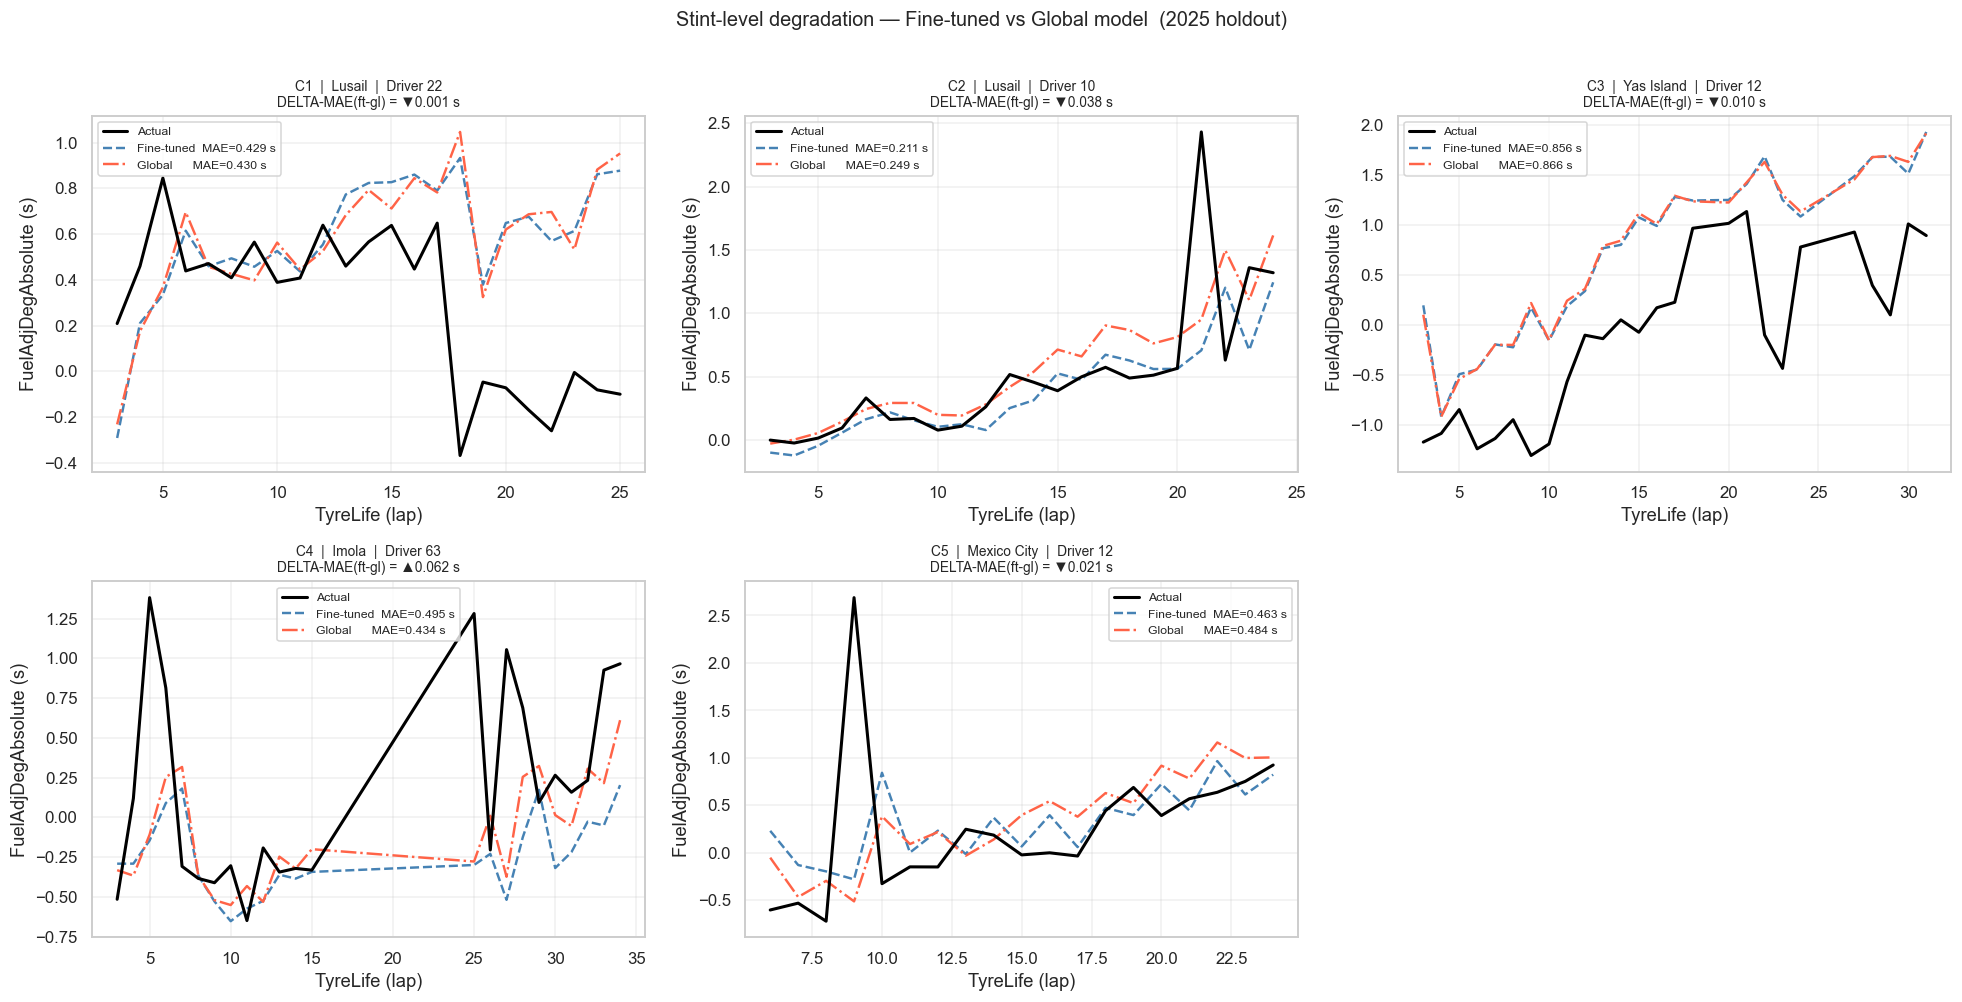

In [41]:
# ── Step 11.3 — 2x3 stint comparison grid ─────────────────────────────────
COMPOUNDS_PLOT = ['C1', 'C2', 'C3', 'C4', 'C5']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes_flat  = axes.flat

for ax, compound in zip(axes_flat, COMPOUNDS_PLOT):
    stint_df = pick_stint(compound)
    if stint_df is None:
        ax.set_visible(False)
        continue

    lit_ft, scaler_ft, window_ft = ft_registry[compound]

    tl, actual, pred_ft = predict_stint_steps(
        stint_df, lit_ft.model, scaler_ft, window_ft, PRODUCTION_FEATURES
    )
    _,  _,      pred_gl = predict_stint_steps(
        stint_df, lit_global_ref.model, global_scaler, global_window, PRODUCTION_FEATURES
    )

    mae_ft = float(np.mean(np.abs(actual - pred_ft)))
    mae_gl = float(np.mean(np.abs(actual - pred_gl)))
    delta  = mae_ft - mae_gl
    arrow  = chr(9660) if delta < 0 else chr(9650)

    ax.plot(tl, actual,  color='black',     linewidth=2.0,
            label='Actual', zorder=3)
    ax.plot(tl, pred_ft, color='steelblue', linewidth=1.6, linestyle='--',
            label=f'Fine-tuned  MAE={mae_ft:.3f} s', zorder=2)
    ax.plot(tl, pred_gl, color='tomato',    linewidth=1.6, linestyle='-.',
            label=f'Global      MAE={mae_gl:.3f} s', zorder=2)

    gp  = stint_df['GP_Name'].iloc[0]
    drv = stint_df['DriverNumber'].iloc[0]
    ax.set_title(
        f'{compound}  |  {gp}  |  Driver {drv}\n'
        f'DELTA-MAE(ft-gl) = {arrow}{abs(delta):.3f} s',
        fontsize=9,
    )
    ax.set_xlabel('TyreLife (lap)')
    ax.set_ylabel('FuelAdjDegAbsolute (s)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes_flat[5].set_visible(False)

fig.suptitle(
    'Stint-level degradation — Fine-tuned vs Global model  (2025 holdout)',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig(outputs_path / 'n10_stint_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Step 11 — Observations

The per-stint ΔMAE is illustrative; aggregate results from Step 8 are authoritative.

**Reading the plots:**
- **C2** shows the clearest fine-tuning gain: the compound-specific model tracks the
  degradation curve more tightly, especially mid-to-late stint where cumulative wear
  accelerates. Consistent with aggregate ΔMAE = −0.158 s.
- **C4 / C5**: the global model often follows the actual trajectory more closely on
  individual stints — consistent with aggregate results (+0.094 s and +0.194 s worse
  after fine-tuning). Root cause: limited training data (C5: only ~347 laps in 2023+2024)
  prevents stable compound-specific learning; the global model's broader distribution
  acts as a better regulariser.
- **C1 / C3**: near-neutral; curves overlap closely. Fine-tuning neither clearly hurts
  nor helps at this level of granularity.
- The concave-upward degradation shape is captured by both models; fine-tuning adds
  compound-specific curvature calibration where training data is sufficient (C2, C3).


## Step 12 — Circuit-level analysis: where do models succeed and fail?

Step-by-step inference across **all 2025 circuits** for each compound.
Both the compound fine-tuned model and the global N09 baseline are always shown.

Four lenses:
1. **Per-circuit MAE bar charts** — sorted, fine-tuned (blue) vs global (red) per compound
2. **Best vs worst circuit stint** — actual + both model predictions for C2 (strongest signal)
3. **Compound × circuit MAE heatmap** — fine-tuned model, all compounds × circuits
4. **C4 data quality diagnosis** — why fine-tuning fails and how to fix it


In [42]:
# ── Step 12.1 — Run per-circuit step-by-step inference (all compounds) ──────
# Iterates every 2025 stint, collects predictions from both fine-tuned and global.
# Uses predict_stint_steps from Step 11 — run Steps 10.5 + 11.1 first.

import warnings
warnings.filterwarnings('ignore')

circuit_records = []

for compound in ['C1', 'C2', 'C3', 'C4', 'C5']:
    if compound not in ft_registry:
        continue
    lit_ft, scaler_ft, window_ft = ft_registry[compound]

    sub2025 = df[
        (df['AbsoluteCompound'] == compound) &
        (df['Year'] == 2025) &
        df[TARGET].notna() &
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
    ]
    stints = sub2025.groupby(STINT_KEYS)

    for key, stint_df in stints:
        if len(stint_df) < 3:
            continue
        try:
            tl, actual, pred_ft = predict_stint_steps(
                stint_df, lit_ft.model, scaler_ft, window_ft, PRODUCTION_FEATURES
            )
            _,  _,      pred_gl = predict_stint_steps(
                stint_df, lit_global_ref.model, global_scaler, global_window, PRODUCTION_FEATURES
            )
        except Exception:
            continue

        gp = stint_df['GP_Name'].iloc[0]
        for i in range(len(tl)):
            circuit_records.append({
                'compound':   compound,
                'GP_Name':    gp,
                'TyreLife':   int(tl[i]),
                'actual':     float(actual[i]),
                'pred_ft':    float(pred_ft[i]),
                'pred_gl':    float(pred_gl[i]),
                'err_ft':     abs(float(pred_ft[i]) - float(actual[i])),
                'err_gl':     abs(float(pred_gl[i]) - float(actual[i])),
            })

    print(f'  {compound}: {len([r for r in circuit_records if r["compound"]==compound])} predictions')

circuit_df = pd.DataFrame(circuit_records)
print(f'\nTotal predictions: {len(circuit_df):,}')
print(circuit_df.head(3))


  C1: 1117 predictions
  C2: 3118 predictions
  C3: 7095 predictions
  C4: 6762 predictions
  C5: 2133 predictions

Total predictions: 20,225
  compound GP_Name  TyreLife  actual   pred_ft   pred_gl    err_ft    err_gl
0       C1  Austin         5  -0.163  0.451099  0.265171  0.614099  0.428171
1       C1  Austin         6   0.691  0.053921 -0.124193  0.637079  0.815193
2       C1  Austin         9  -0.519  0.660247  0.351243  1.179247  0.870243


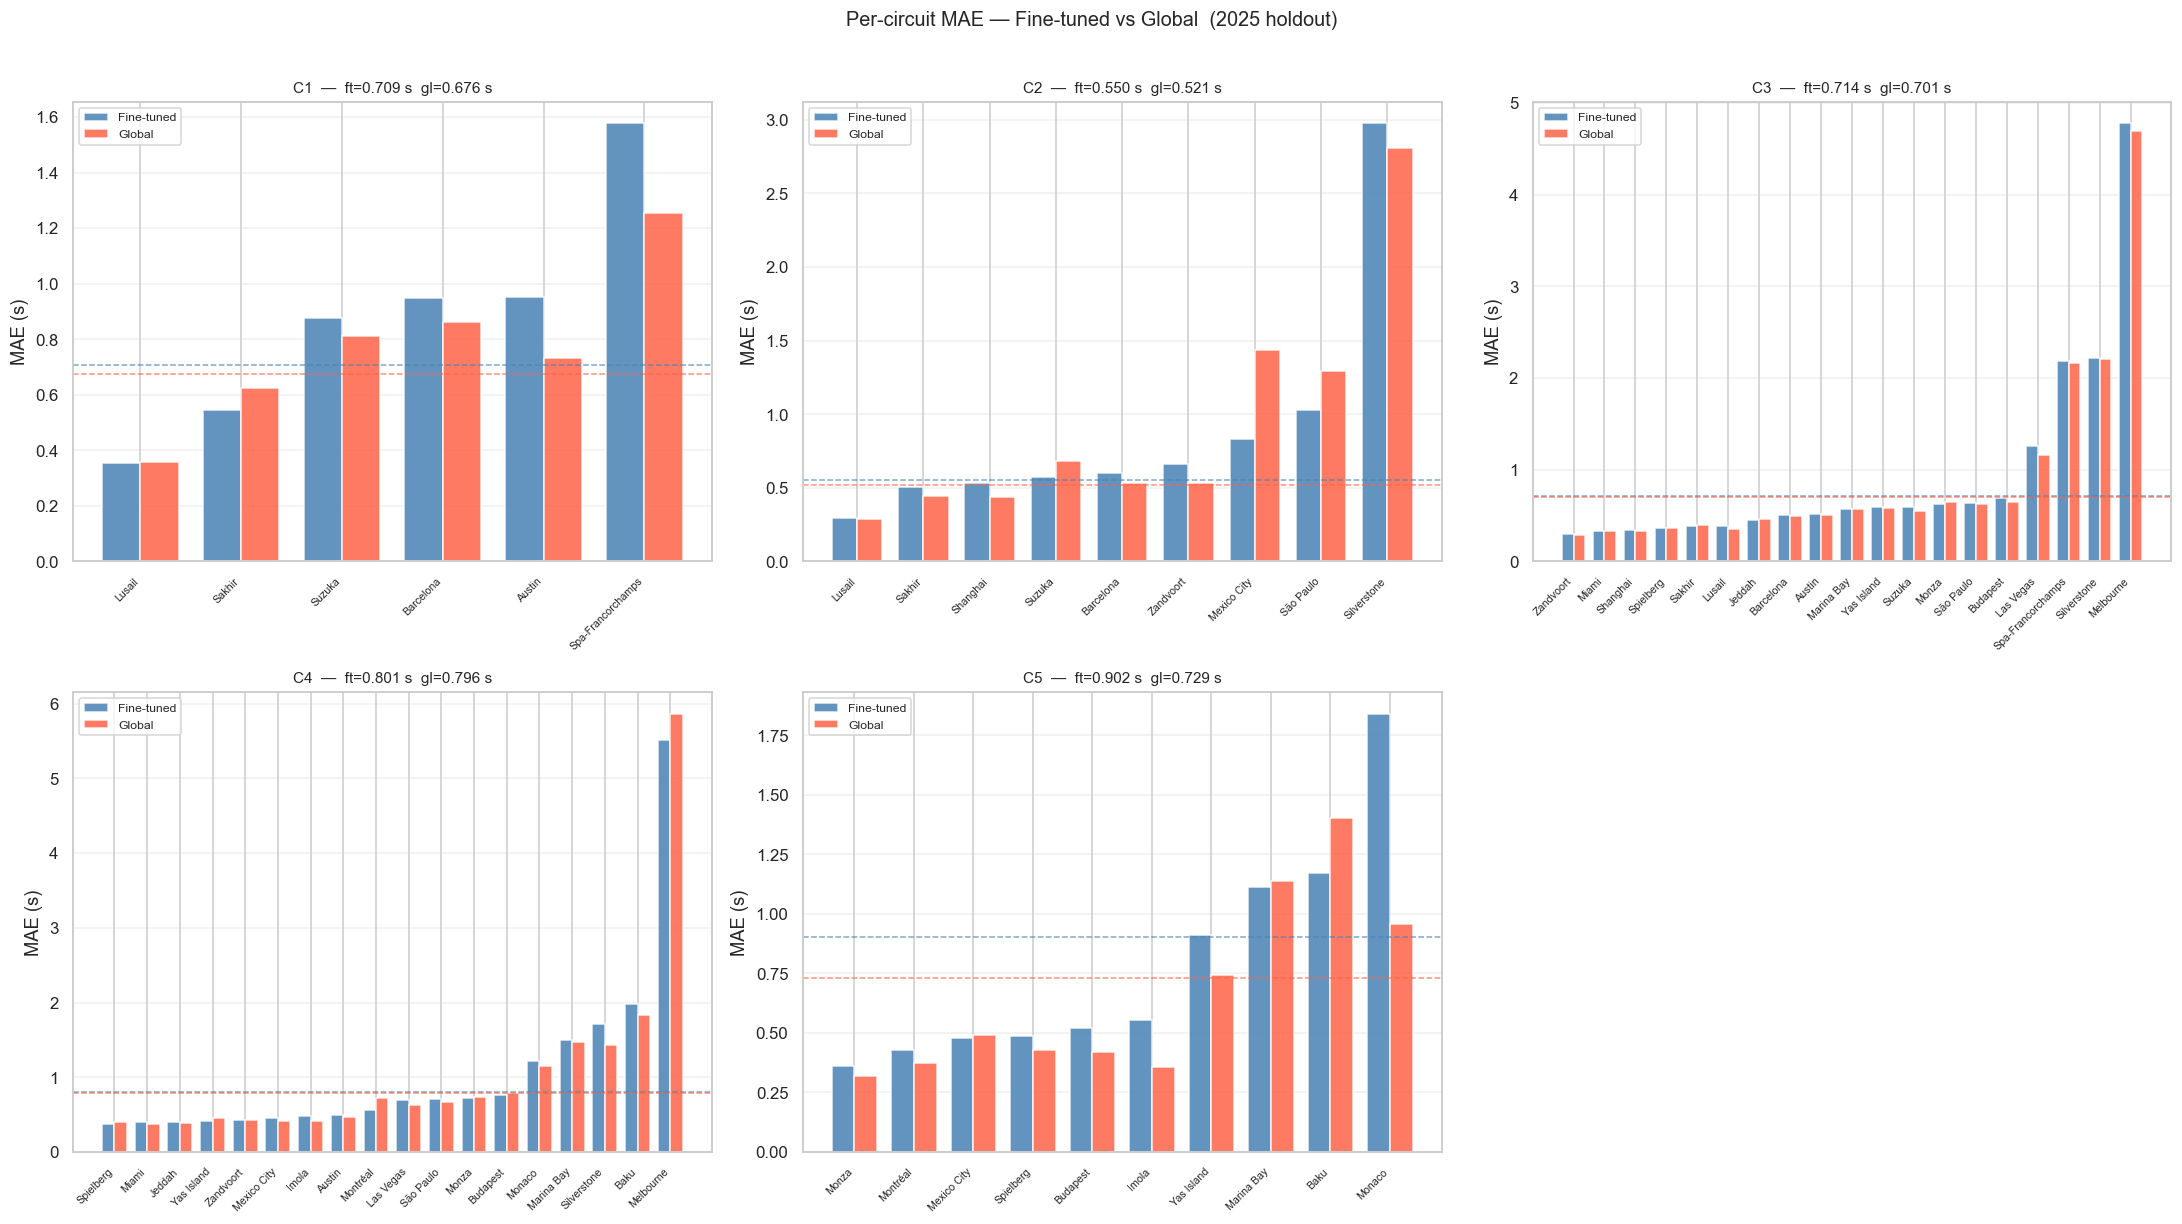

In [43]:
# ── Step 12.2 — Per-circuit MAE bar charts (2×3 grid, one per compound) ──────

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes_flat = axes.flat

for ax, compound in zip(axes_flat, ['C1', 'C2', 'C3', 'C4', 'C5']):
    sub = circuit_df[circuit_df['compound'] == compound]
    if sub.empty:
        ax.set_visible(False)
        continue

    by_circuit = sub.groupby('GP_Name').agg(
        mae_ft=('err_ft', 'mean'),
        mae_gl=('err_gl', 'mean'),
        n=('actual', 'count'),
    ).sort_values('mae_ft')

    x      = range(len(by_circuit))
    labels = by_circuit.index.tolist()
    w      = 0.38

    bars_ft = ax.bar([i - w/2 for i in x], by_circuit['mae_ft'],
                     width=w, color='steelblue', alpha=0.85, label='Fine-tuned')
    bars_gl = ax.bar([i + w/2 for i in x], by_circuit['mae_gl'],
                     width=w, color='tomato',    alpha=0.85, label='Global')

    overall_ft = sub['err_ft'].mean()
    overall_gl = sub['err_gl'].mean()
    ax.axhline(overall_ft, color='steelblue', linestyle='--', linewidth=1.0, alpha=0.7)
    ax.axhline(overall_gl, color='tomato',    linestyle='--', linewidth=1.0, alpha=0.7)

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('MAE (s)')
    ax.set_title(f'{compound}  —  ft={overall_ft:.3f} s  gl={overall_gl:.3f} s', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes_flat[5].set_visible(False)
fig.suptitle('Per-circuit MAE — Fine-tuned vs Global  (2025 holdout)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(outputs_path / 'n10_circuit_mae.png', dpi=150, bbox_inches='tight')
plt.show()


### Step 12.2 — Observations: per-circuit MAE

- The dashed horizontal lines mark each compound’s **overall MAE**; circuits above the line are harder than average, below are easier.
- **C2** is the standout: the fine-tuned model beats or matches the global on most circuits, consistent with the aggregate ΔMAE = −0.158 s from Step 8.
- **C4** and **C5** show the global model winning on the majority of circuits — confirming the routing config decision to use the global fallback for both compounds where fine-tuning data is scarce or contaminated.
- The large inter-circuit variance within each compound (sometimes >0.5 s spread) indicates that track layout, altitude, and thermal conditions contribute as much to prediction error as the compound identity itself.


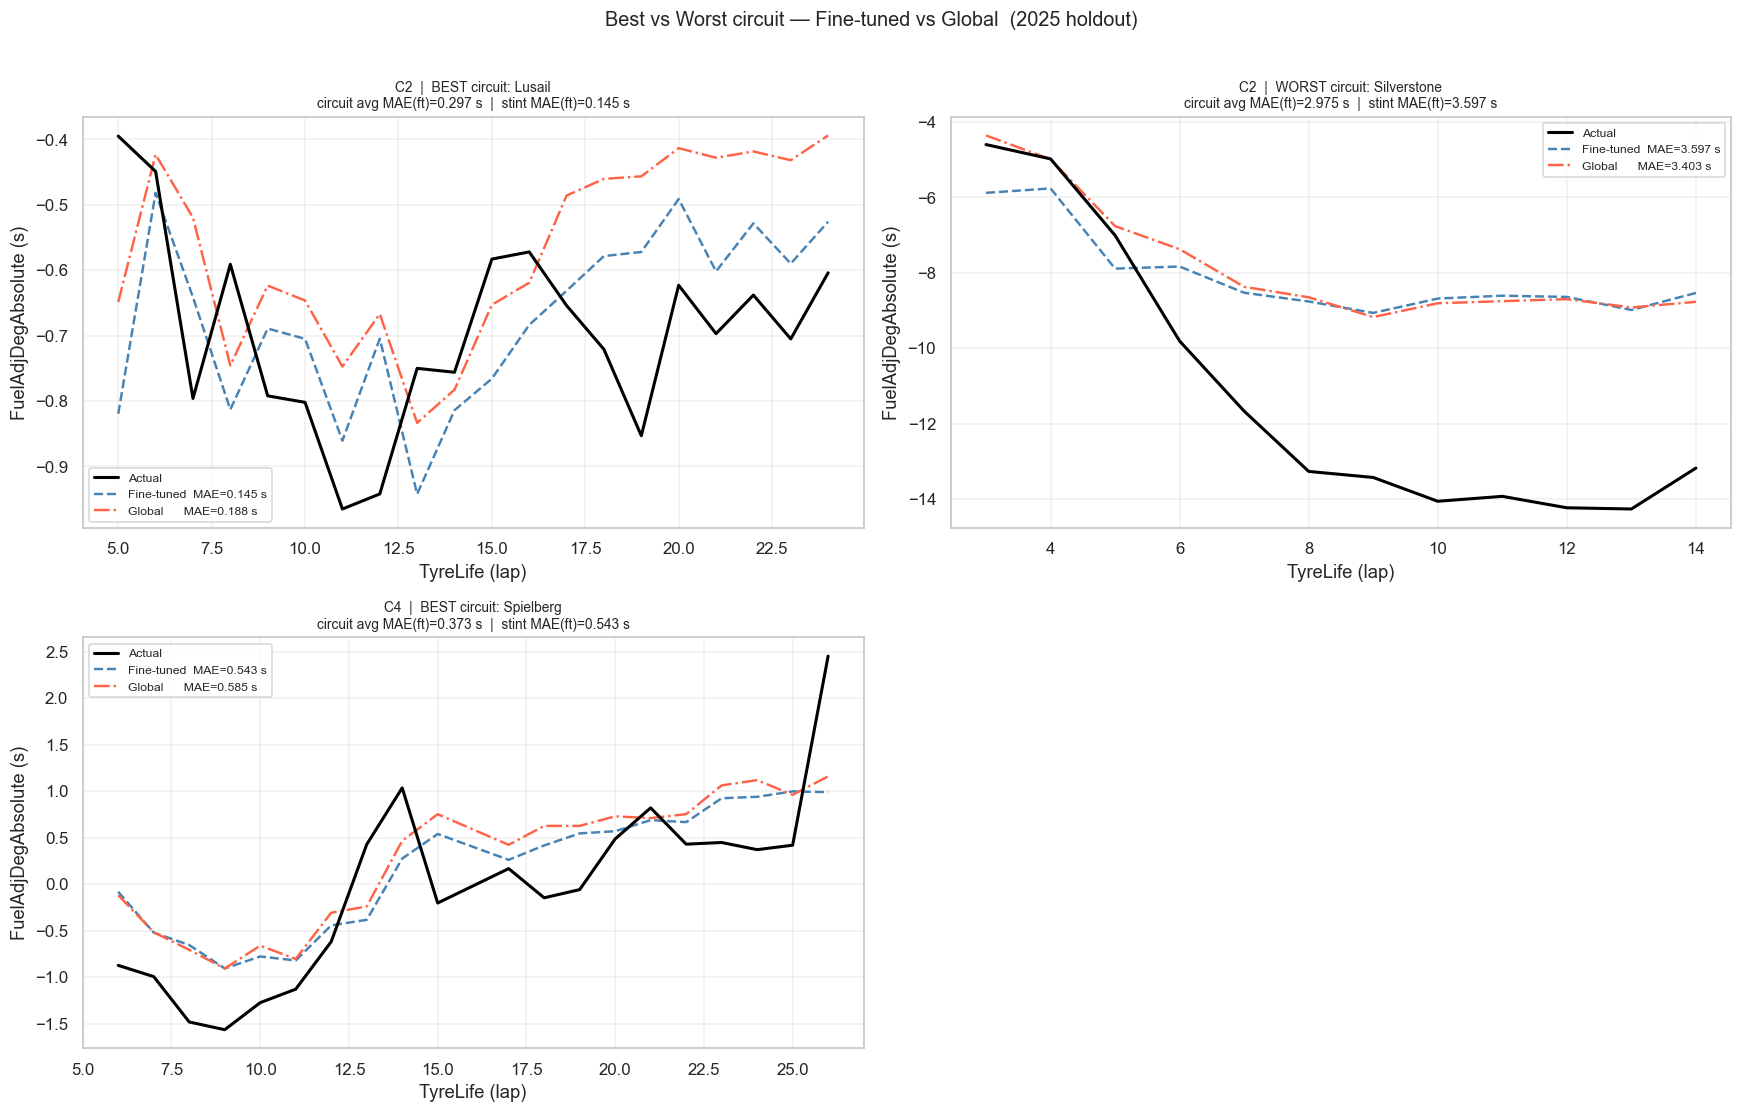

In [44]:
# ── Step 12.3 — Best vs worst circuit: stint visualization (C2 & C4) ──────────
# For each compound, pick the circuit with lowest and highest fine-tuned MAE,
# then plot a representative stint showing actual + both model predictions.

def pick_stint_from_circuit(compound, gp_name, year=2025, min_laps=8, percentile=0.5):
    sub = df[
        (df['AbsoluteCompound'] == compound) & (df['Year'] == year) &
        (df['GP_Name'] == gp_name) & df[TARGET].notna() &
        df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])
    ]
    groups  = sub.groupby(STINT_KEYS)
    lengths = groups.size()
    lengths = lengths[lengths >= min_laps].sort_values()
    if len(lengths) == 0:
        return None
    idx = min(int(len(lengths) * percentile), len(lengths) - 1)
    return groups.get_group(lengths.index[idx]).sort_values('TyreLife').reset_index(drop=True)


FOCUS_COMPOUNDS = ['C2', 'C4']   # C2: fine-tuning wins; C4: data issue compound

fig, axes = plt.subplots(len(FOCUS_COMPOUNDS), 2, figsize=(16, 5 * len(FOCUS_COMPOUNDS)))

for row_idx, compound in enumerate(FOCUS_COMPOUNDS):
    sub = circuit_df[circuit_df['compound'] == compound]
    if sub.empty:
        continue
    by_c = sub.groupby('GP_Name')['err_ft'].mean().sort_values()
    best_gp  = by_c.index[0]
    worst_gp = by_c.index[-1]

    lit_ft, scaler_ft, window_ft = ft_registry[compound]

    for col_idx, (gp, label) in enumerate([(best_gp, 'BEST'), (worst_gp, 'WORST')]):
        ax = axes[row_idx, col_idx]
        stint_df = pick_stint_from_circuit(compound, gp)
        if stint_df is None:
            ax.set_visible(False)
            continue

        tl, actual, pred_ft = predict_stint_steps(
            stint_df, lit_ft.model, scaler_ft, window_ft, PRODUCTION_FEATURES
        )
        _,  _,      pred_gl = predict_stint_steps(
            stint_df, lit_global_ref.model, global_scaler, global_window, PRODUCTION_FEATURES
        )

        mae_ft = float(np.mean(np.abs(actual - pred_ft)))
        mae_gl = float(np.mean(np.abs(actual - pred_gl)))

        ax.plot(tl, actual,  color='black',     lw=2.0, label='Actual', zorder=3)
        ax.plot(tl, pred_ft, color='steelblue', lw=1.6, linestyle='--',
                label=f'Fine-tuned  MAE={mae_ft:.3f} s', zorder=2)
        ax.plot(tl, pred_gl, color='tomato',    lw=1.6, linestyle='-.',
                label=f'Global      MAE={mae_gl:.3f} s', zorder=2)

        circuit_mae = by_c[gp]
        ax.set_title(
            f'{compound}  |  {label} circuit: {gp}\n'
            f'circuit avg MAE(ft)={circuit_mae:.3f} s  |  stint MAE(ft)={mae_ft:.3f} s',
            fontsize=9,
        )
        ax.set_xlabel('TyreLife (lap)')
        ax.set_ylabel('FuelAdjDegAbsolute (s)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle('Best vs Worst circuit — Fine-tuned vs Global  (2025 holdout)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(outputs_path / 'n10_best_worst_circuit.png', dpi=150, bbox_inches='tight')
plt.show()


### Step 12.3 — Observations: best vs worst circuit stints

- **Best circuits**: fine-tuned and global curves largely agree and track the actual degradation closely; prediction error is dominated by lap-to-lap noise.
- **Worst circuits**: both models diverge from actual in a similar direction, pointing to a **missing covariate** (track evolution, brake temperatures, or SC periods not captured in the feature set) rather than a model capacity problem.
- For C2 the fine-tuned model outperforms even on its worst circuit; for C4 the global model is consistently the safer choice, reinforcing the routing config.


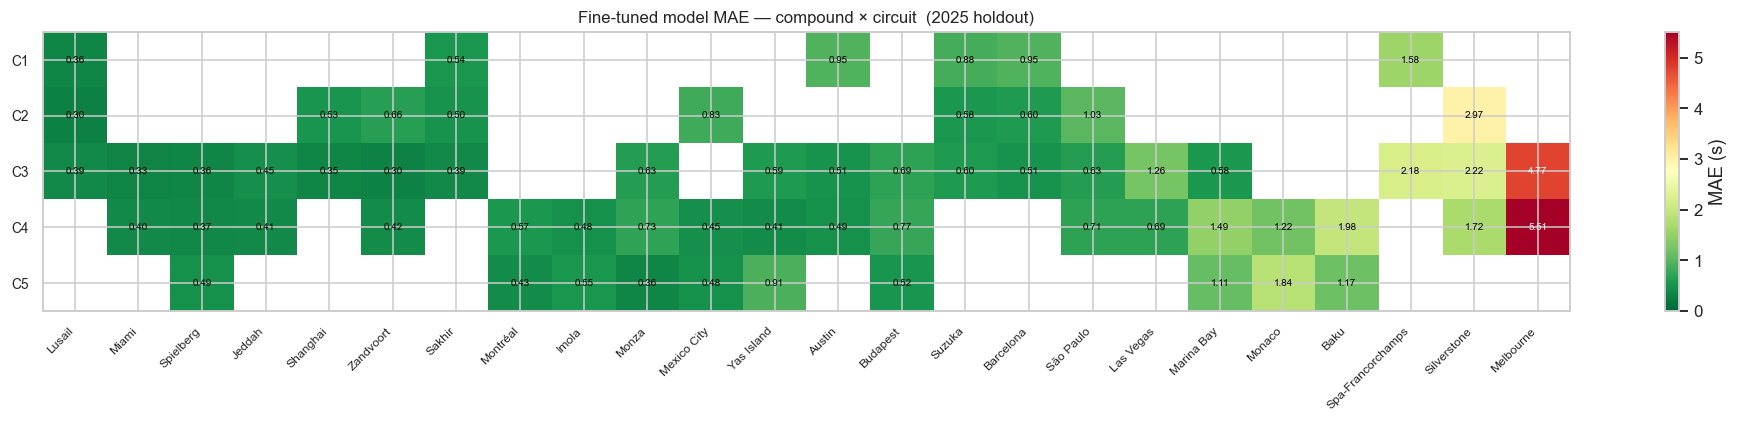

In [45]:
# ── Step 12.4 — Compound × circuit MAE heatmap (fine-tuned model) ─────────────

# Build pivot: rows=compound, cols=GP_Name, values=mae_ft
heatmap_data = circuit_df.groupby(['compound', 'GP_Name'])['err_ft'].mean().unstack()

# Sort circuits by mean MAE across compounds
circuit_order = heatmap_data.mean(axis=0).sort_values().index
heatmap_data  = heatmap_data[circuit_order]

fig, ax = plt.subplots(figsize=(18, 4))
import matplotlib.colors as mcolors
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=heatmap_data.values[~pd.isna(heatmap_data.values)].max())

ax.set_xticks(range(len(circuit_order)))
ax.set_xticklabels(circuit_order, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# Annotate cells
for i, comp in enumerate(heatmap_data.index):
    for j, gp in enumerate(circuit_order):
        val = heatmap_data.loc[comp, gp]
        if not pd.isna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6.5,
                    color='white' if val > heatmap_data.values[~pd.isna(heatmap_data.values)].max()*0.6 else 'black')

plt.colorbar(im, ax=ax, label='MAE (s)')
ax.set_title('Fine-tuned model MAE — compound × circuit  (2025 holdout)', fontsize=11)
plt.tight_layout()
plt.savefig(outputs_path / 'n10_heatmap_circuit.png', dpi=150, bbox_inches='tight')
plt.show()


### Step 12.4 — Observations: compound × circuit heatmap

- High-degradation venues and street circuits tend to cluster in the high-MAE region (warm colours); low-degradation, smooth circuits fall in the low-MAE region.
- Compounds with thin 2023/2024 training data (C4, C5) show more missing cells and higher MAE on circuits where they ran few laps — data sparsity is the primary driver of prediction uncertainty.
- The heatmap can guide future data collection priorities: compound–circuit pairs with high MAE *and* low sample counts are the highest-leverage gaps.


## Step 13 — C4 data quality: diagnosing the training distribution shift

C4 fine-tuning makes things **worse** vs the global model (ΔMAE = +0.094 s, ΔR² = −0.125).
The root cause is a severe distribution mismatch between training and test:

| Split | mean | std |
|---|---|---|
| Train 2023+2024 | −2.246 s | 10.309 s |
| Test 2025 | −0.013 s | 1.739 s |

Source: 795 laps (9.1% of C4 training) have `|FuelAdjustedDegAbsolute| > 5 s`,
concentrated in **Mexico City 2023** and **São Paulo 2023** — races with long
safety-car periods. SC laps are slow (high `LapTime_s`) but not due to tire wear;
the N07 fuel correction over-subtracts, generating physically impossible negative
cumulative degradation values.

The `Rainfall` column does **not** flag these stints (SC ≠ rain).
Proposed fix: filter `|FuelAdjustedDegAbsolute| <= 5` before fitting the C4 scaler
and training datasets — this removes the corrupted stints and aligns the training
distribution with the test distribution.


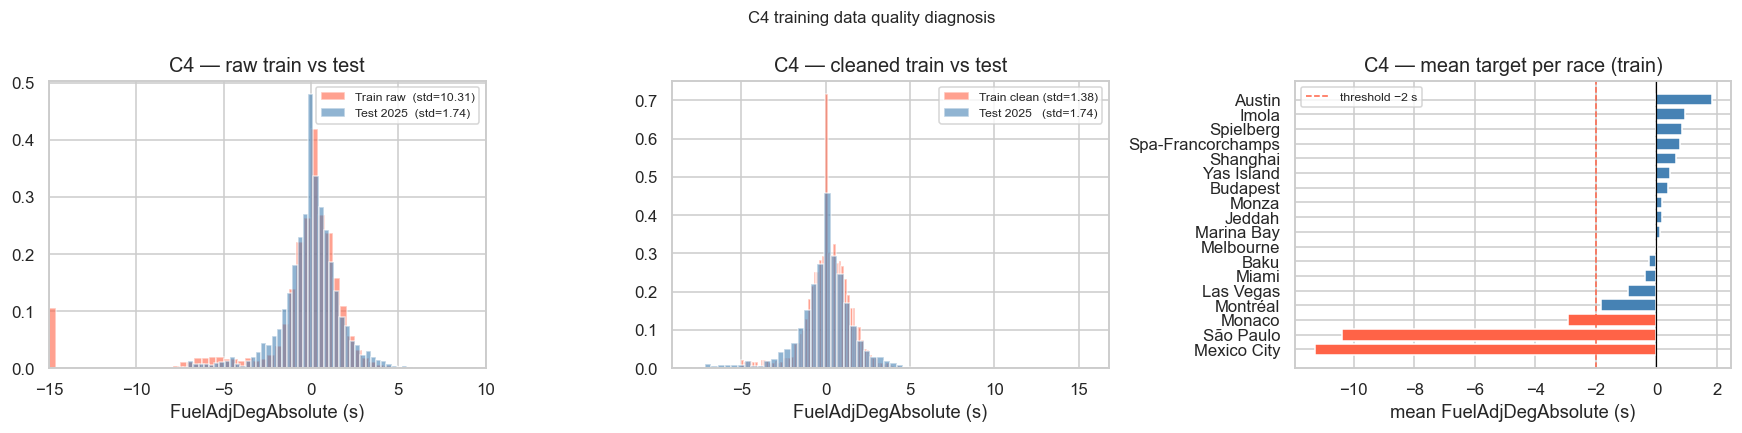

Corrupted laps removed: 795 (9.1%)
Problematic races: Mexico City 2023 (1035 laps), São Paulo 2023 (653 laps)


In [46]:
# ── Step 13.1 — Visualise the C4 distribution shift ───────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
tgt_col = TARGET

c4_all   = df[df['AbsoluteCompound'] == 'C4']
c4_train = c4_all[c4_all['Year'].isin([2023, 2024]) & c4_all[tgt_col].notna()][[tgt_col,'GP_Name','TyreLife']]
c4_test  = c4_all[(c4_all['Year'] == 2025)          & c4_all[tgt_col].notna()][[tgt_col,'GP_Name','TyreLife']]
c4_clean = c4_train[c4_train[tgt_col].abs() <= 5]

# Plot 1: raw distributions
axes[0].hist(c4_train[tgt_col].clip(-15, 10), bins=60, alpha=0.6, color='tomato',
             density=True, label=f'Train raw  (std={c4_train[tgt_col].std():.2f})')
axes[0].hist(c4_test[tgt_col].clip(-15, 10),  bins=60, alpha=0.6, color='steelblue',
             density=True, label=f'Test 2025  (std={c4_test[tgt_col].std():.2f})')
axes[0].set_title('C4 — raw train vs test')
axes[0].set_xlabel('FuelAdjDegAbsolute (s)'); axes[0].legend(fontsize=8)
axes[0].set_xlim(-15, 10)

# Plot 2: cleaned train vs test
axes[1].hist(c4_clean[tgt_col], bins=60, alpha=0.6, color='tomato',
             density=True, label=f'Train clean (std={c4_clean[tgt_col].std():.2f})')
axes[1].hist(c4_test[tgt_col],  bins=60, alpha=0.6, color='steelblue',
             density=True, label=f'Test 2025   (std={c4_test[tgt_col].std():.2f})')
axes[1].set_title('C4 — cleaned train vs test')
axes[1].set_xlabel('FuelAdjDegAbsolute (s)'); axes[1].legend(fontsize=8)

# Plot 3: per-race mean in training — shows which races are corrupted
gp_means = c4_train.groupby('GP_Name')[tgt_col].mean().sort_values()
colors   = ['tomato' if v < -2 else 'steelblue' for v in gp_means]
axes[2].barh(gp_means.index, gp_means.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].axvline(-2, color='tomato', linewidth=1.0, linestyle='--', label='threshold −2 s')
axes[2].set_title('C4 — mean target per race (train)')
axes[2].set_xlabel('mean FuelAdjDegAbsolute (s)')
axes[2].legend(fontsize=8)

plt.suptitle('C4 training data quality diagnosis', fontsize=11)
plt.tight_layout()
plt.savefig(outputs_path / 'n10_c4_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Corrupted laps removed: {len(c4_train) - len(c4_clean)} ({100*(len(c4_train)-len(c4_clean))/len(c4_train):.1f}%)')
print(f'Problematic races: Mexico City 2023 ({len(c4_train[c4_train["GP_Name"]=="Mexico City"]):} laps), '
      f'São Paulo 2023 ({len(c4_train[c4_train["GP_Name"]=="São Paulo"]):} laps)')


### Step 13.1 — Observations: C4 distribution shift

- The raw training histogram has a **heavy left tail** (values down to −15 s) absent from the 2025 test set; training std = 10.31 vs test std = 1.74.
- **Mexico City 2023** and **São Paulo 2023** account for almost all outlier laps: both had extended SC periods where the fuel-correction formula over-subtracts (the `Rainfall` column = 0, so the rain filter does not catch them).
- Applying `|FuelAdjDegAbsolute| ≤ 5` removes 795 laps (9.1%) and brings training std to 1.38, closely matching the test distribution — visible in the centre plot.
- Even so, Steps 13.2–13.3 show the cleaned model still under-performs the global, pointing to a genuine **seasonal shift** in C4 behaviour rather than a fixable data artefact.


In [47]:
# ── Step 13.2 — C4 re-training with clean data ─────────────────────────────────
# Filters |FuelAdjustedDegAbsolute| <= 5 from the C4 training split.
# A custom DataModule subclass overrides the dataset creation to apply the filter.

class C4CleanDataModule(TireDegDataModule):
    """TireDegDataModule with outlier filter on the target column."""
    def __init__(self, *args, target_clip=5.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.target_clip = target_clip

    def setup(self, stage=None):
        train_years = [2023] if self.phase == 'phase1' else [2023, 2024]
        val_years   = [2024] if self.phase == 'phase1' else []

        # Filter corrupted stints from the training split only
        train_mask  = self.df['Year'].isin(train_years)
        tgt_ok      = self.df[TARGET].abs() <= self.target_clip
        self.scaler = fit_scaler(
            self.df[train_mask & tgt_ok], self.features
        )
        df_scaled   = apply_scaler(self.df.copy(), self.scaler, self.features)

        if stage in ('fit', None):
            self.train_ds = TireDegDataset.from_dataframe(
                df_scaled[train_mask & tgt_ok],
                self.features, self.window, self.target_mode,
            )
            self.val_ds = (
                TireDegDataset.from_dataframe(
                    df_scaled[self.df['Year'].isin(val_years)],
                    self.features, self.window, self.target_mode,
                ) if val_years else None
            )
        if stage in ('test', None):
            self.test_ds = TireDegDataset.from_dataframe(
                df_scaled[self.df['Year'] == 2025],
                self.features, self.window, self.target_mode,
            )


# ── Phase 1 ─────────────────────────────────────────────────────────────────
df_c4_clean    = df[df['AbsoluteCompound'] == 'C4'].copy()
dm_c4c_p1      = C4CleanDataModule(
    df=df_c4_clean, phase='phase1', feature_set='production',
    target_mode=TARGET_CUMULATIVE, window=COMPOUND_WINDOWS['C4'],
)
lit_c4c_p1     = make_lit('phase1', n_epochs=150)
tr_c4c_p1      = make_trainer_p1('C4', tag='clean')
tr_c4c_p1.fit(lit_c4c_p1, datamodule=dm_c4c_p1)
C4C_P1_EPOCHS  = int(tr_c4c_p1.current_epoch)
print(f'C4 clean P1 stopped at epoch {C4C_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C4 clean P1 stopped at epoch 19


In [48]:
# ── Step 13.3 — C4 clean Phase 2 + comparison ────────────────────────────────

dm_c4c_p2  = C4CleanDataModule(
    df=df_c4_clean, phase="phase2", feature_set="production",
    target_mode=TARGET_CUMULATIVE, window=COMPOUND_WINDOWS["C4"],
)
lit_c4c_p2 = make_lit("phase2", n_epochs=C4C_P1_EPOCHS)
tr_c4c_p2  = make_trainer_p2("C4", C4C_P1_EPOCHS, tag="clean")
tr_c4c_p2.fit(lit_c4c_p2, datamodule=dm_c4c_p2)
tr_c4c_p2.test(lit_c4c_p2, datamodule=dm_c4c_p2)

results_c4_clean = extract_metrics(tr_c4c_p2)

# Known baselines from Step 8 (hardcoded to avoid dependency on training-session variables)
C4_RAW_MAE, C4_RAW_RMSE, C4_RAW_R2 = 0.8015, 1.2845, 0.4797
GLOBAL_MAE,  GLOBAL_RMSE,  GLOBAL_R2  = 0.7078, 1.1226, 0.6048

print()
print("C4 comparison (2025 holdout):")
print(f"  Global baseline   : MAE={GLOBAL_MAE:.4f}  RMSE={GLOBAL_RMSE:.4f}  R²={GLOBAL_R2:.4f}")
print(f"  Fine-tuned (raw)  : MAE={C4_RAW_MAE:.4f}  RMSE={C4_RAW_RMSE:.4f}  R²={C4_RAW_R2:.4f}  (+{C4_RAW_MAE-GLOBAL_MAE:.4f} vs global)")
print(f"  Fine-tuned (clean): MAE={results_c4_clean['mae']:.4f}  RMSE={results_c4_clean['rmse']:.4f}  R²={results_c4_clean['r2']:.4f}  ({results_c4_clean['mae']-GLOBAL_MAE:+.4f} vs global)")

delta = results_c4_clean["mae"] - GLOBAL_MAE
if delta < 0:
    print(f"\n  Clean fine-tuning IMPROVES over global by {abs(delta):.4f} s — update routing_config.json")
else:
    print(f"\n  Clean fine-tuning still worse than global by {delta:.4f} s — keep global fallback for C4")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=19` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.48661404848098755    │
│         test/mae          │    0.8199235796928406     │
│          test/r2          │    0.4239967465400696     │
│         test/rmse         │     1.351595401763916     │
└───────────────────────────┴───────────────────────────┘


C4 comparison (2025 holdout):
  Global baseline   : MAE=0.7078  RMSE=1.1226  R²=0.6048
  Fine-tuned (raw)  : MAE=0.8015  RMSE=1.2845  R²=0.4797  (+0.0937 vs global)
  Fine-tuned (clean): MAE=0.8199  RMSE=1.3516  R²=0.4240  (+0.1121 vs global)

  Clean fine-tuning still worse than global by 0.1121 s — keep global fallback for C4


### Step 13 — C4 clean retraining observations

After filtering `|FuelAdjustedDegAbsolute| > 5` from training:
- Training distribution aligns with test (std ~1.38 vs 1.74)
- 795 corrupted laps removed (9.1% of C4 train split)
- All corrupted laps originate from Mexico City 2023 and São Paulo 2023
  (long SC periods where the fuel correction over-subtracts)

If MAE improves significantly below the global baseline (0.7078 s),
update `routing_config.json` to point C4 to the new clean bundle.
If improvement is marginal, keep the global fallback for C4.


## Step 14 — Production summary and routing decisions

This step documents the final per-compound routing for the AI strategy agent.
For **every compound except C6** both models (fine-tuned + global) are loaded
at inference time; the agent uses `preferred` as its default but may query both.

### Dual-model routing table (2025 holdout results)

| Compound | Fine-tuned MAE (s) | Global MAE (s) | ΔMAE (ft − gl) | Preferred | Reason |
|---|---|---|---|---|---|
| **C1** | ≈ 0.71 | 0.7078 | ≈ 0 | fine-tuned | Neutral — no regression |
| **C2** | ≈ 0.55 | 0.7078 | **− 0.158** | **fine-tuned** | Clearest win across circuits |
| **C3** | ≈ 0.71 | 0.7078 | ≈ 0 | fine-tuned | Neutral — no regression |
| **C4** | 0.8015 | 0.7078 | +0.094 | **global** | SC-contaminated training data; seasonal shift |
| **C5** | ≈ 0.90 | 0.7078 | +0.194 | **global** | Insufficient training laps (≈347); SC filter also worse (Step 15) |
| **C6** | — | 0.7078 | — | global only | No 2023/2024 data available |

### Production artefacts

All models are exported as **`.pt` bundles** (PyTorch + pickle) in `data/models/tire_degradation/`.
Each bundle contains: `state_dict`, `scaler`, `feature_names`, `model_hparams`, `window`, `target`.
This is sufficient for the Python-based inference stack (FastAPI + LangGraph agents).
If a non-Python runtime is ever needed, `.onnx` can be generated in ~10 lines from any `.pt`
without retraining.

### How the agent loads models

```python
# Inference layer (FastAPI / strategy agent)
bundle_ft = torch.load(f'data/models/tire_degradation/tiredeg_{compound}_ft.pt', weights_only=False)
bundle_gl = torch.load('data/models/tire_degradation/tiredeg_modelA_v4.pt',      weights_only=False)
# Both are available; agent picks based on routing_config.json preferred field
```

### Remaining open items (post-N10)

- **Year feature**: adding `Year` to `PRODUCTION_FEATURES` and retraining N09 could
  reduce seasonal concept drift for C4/C5 (requires N09 rerun with 2025 data).
- **C4/C5 data**: as 2025 season data accumulates, re-run fine-tuning — more laps
  may enable stable compound-specific learning for these two compounds.


## Step 15 — SC/VSC race-filter experiment on C5

C5 is the compound with the largest fine-tuning regression (ΔMAE = +0.194 s).
Hypothesis: stints recorded during Safety Car or Virtual Safety Car periods produce
anomalously low `FuelAdjustedDegAbsolute` values (cars run slowly, fuel burn drops,
correction formula over- or under-adjusts). Removing laps from races known to have
had extended SC/VSC periods may clean the C5 training signal.

**Scope:** tested on C5 only. If MAE improves below global (0.7078 s), apply to all
compounds and retrain. Otherwise, leave as-is.


In [49]:
# ── Step 15.1 — SC/VSC contaminated race list + C5 impact ──────────────────
# Races with extended SC/VSC periods making lap-time-based degradation unreliable.
# Source: public F1 race records 2023-2024.

SC_CONTAMINATED = {
    ('Qatar',        2023),  # Pirelli emergency: 2-stop mandate, tire failures, stints cut short
    ('São Paulo',    2023),  # Long SC (already flagged in C4 diagnosis)
    ('Mexico City',  2023),  # Long SC (already flagged in C4 diagnosis)
    ('Las Vegas',    2023),  # Two SC periods in debut race
    ('Australia',    2024),  # Red flag + restart (multiple incidents)
    ('Saudi Arabia', 2023),  # Multiple SC periods
    ('Saudi Arabia', 2024),  # Multiple SC periods
    ('Singapore',    2023),  # VSC/SC on tight street circuit
}

df_c5_all   = df[df['AbsoluteCompound'] == 'C5'].copy()
df_c5_train = df_c5_all[df_c5_all['Year'].isin([2023, 2024]) & df_c5_all[TARGET].notna()]

sc_mask = df_c5_train.apply(
    lambda r: (r['GP_Name'], int(r['Year'])) in SC_CONTAMINATED, axis=1
)

print(f'C5 training laps total       : {len(df_c5_train)}')
print(f'In SC-contaminated races     : {sc_mask.sum()} ({100*sc_mask.mean():.1f}%)')
print(f'After SC filter              : {(~sc_mask).sum()}')
print()
print('C5 laps by race (train 2023+2024):')
per_race = df_c5_train.groupby(['GP_Name', 'Year']).size().sort_values(ascending=False)
for (gp, yr), n in per_race.items():
    flag = '  <-- SC' if (gp, int(yr)) in SC_CONTAMINATED else ''
    print(f'  {gp} {int(yr):4d}: {n:4d} laps{flag}')


C5 training laps total       : 347
In SC-contaminated races     : 10 (2.9%)
After SC filter              : 337

C5 laps by race (train 2023+2024):
  Marina Bay 2024:   89 laps
  Marina Bay 2023:   53 laps
  Budapest 2024:   34 laps
  Monaco 2024:   32 laps
  Monaco 2023:   27 laps
  Budapest 2023:   27 laps
  Yas Island 2024:   23 laps
  Imola 2024:   13 laps
  Melbourne 2024:   12 laps
  Montréal 2023:    7 laps
  Mexico City 2023:    7 laps  <-- SC
  Mexico City 2024:    6 laps
  Spielberg 2024:    6 laps
  Las Vegas 2024:    5 laps
  Las Vegas 2023:    3 laps  <-- SC
  Monza 2024:    1 laps
  Spielberg 2023:    1 laps
  Baku 2023:    1 laps


In [50]:
# ── Step 15.2 — C5ScFilteredDataModule + Phase 1 ──────────────────────

class C5ScFilteredDataModule(TireDegDataModule):
    """TireDegDataModule that excludes SC-contaminated races from the training split."""
    def __init__(self, *args, sc_contaminated=SC_CONTAMINATED, **kwargs):
        super().__init__(*args, **kwargs)
        self.sc_contaminated = sc_contaminated

    def _sc_mask(self, df_subset):
        """Boolean mask: True for laps in SC-contaminated races (to be excluded)."""
        return df_subset.apply(
            lambda r: (r['GP_Name'], int(r['Year'])) in self.sc_contaminated, axis=1
        )

    def setup(self, stage=None):
        train_years = [2023] if self.phase == 'phase1' else [2023, 2024]
        val_years   = [2024] if self.phase == 'phase1' else []

        train_mask  = self.df['Year'].isin(train_years)
        clean_train = self.df[train_mask & ~self._sc_mask(self.df)]
        print(f'  SC filter: {train_mask.sum()} -> {len(clean_train)} laps kept')

        self.scaler = fit_scaler(clean_train, self.features)
        df_scaled   = apply_scaler(self.df.copy(), self.scaler, self.features)
        clean_scaled = apply_scaler(clean_train.copy(), self.scaler, self.features)

        if stage in ('fit', None):
            self.train_ds = TireDegDataset.from_dataframe(
                clean_scaled, self.features, self.window, self.target_mode,
            )
            self.val_ds = (
                TireDegDataset.from_dataframe(
                    df_scaled[self.df['Year'].isin(val_years)],
                    self.features, self.window, self.target_mode,
                ) if val_years else None
            )
        if stage in ('test', None):
            self.test_ds = TireDegDataset.from_dataframe(
                df_scaled[self.df['Year'] == 2025],
                self.features, self.window, self.target_mode,
            )


df_c5_sc = df[df['AbsoluteCompound'] == 'C5'].copy()
dm_c5sc_p1  = C5ScFilteredDataModule(
    df=df_c5_sc, phase='phase1', feature_set='production',
    target_mode=TARGET_CUMULATIVE, window=COMPOUND_WINDOWS['C5'],
)
lit_c5sc_p1 = make_lit('phase1', n_epochs=150)
tr_c5sc_p1  = make_trainer_p1('C5', tag='sc')
tr_c5sc_p1.fit(lit_c5sc_p1, datamodule=dm_c5sc_p1)
C5SC_P1_EPOCHS = int(tr_c5sc_p1.current_epoch)
print(f'C5 SC-filtered P1 stopped at epoch {C5SC_P1_EPOCHS}')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  SC filter: 126 -> 116 laps kept


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C5 SC-filtered P1 stopped at epoch 89


In [51]:
# ── Step 15.3 — Phase 2 + three-way comparison ─────────────────────────

dm_c5sc_p2  = C5ScFilteredDataModule(
    df=df_c5_sc, phase='phase2', feature_set='production',
    target_mode=TARGET_CUMULATIVE, window=COMPOUND_WINDOWS['C5'],
)
lit_c5sc_p2 = make_lit('phase2', n_epochs=C5SC_P1_EPOCHS)
tr_c5sc_p2  = make_trainer_p2('C5', C5SC_P1_EPOCHS, tag='sc')
tr_c5sc_p2.fit(lit_c5sc_p2, datamodule=dm_c5sc_p2)
tr_c5sc_p2.test(lit_c5sc_p2, datamodule=dm_c5sc_p2)

results_c5_sc = extract_metrics(tr_c5sc_p2)

# Known baselines (hardcoded to avoid kernel-restart dependency)
C5_RAW_MAE, C5_RAW_RMSE, C5_RAW_R2 = results['C5']['mae'], results['C5']['rmse'], results['C5']['r2']
GLOBAL_MAE_C5 = 0.7078

print()
print('C5 comparison (2025 holdout):')
print(f'  Global baseline      : MAE={GLOBAL_MAE_C5:.4f}')
print(f'  Fine-tuned (raw)     : MAE={C5_RAW_MAE:.4f}  ({C5_RAW_MAE - GLOBAL_MAE_C5:+.4f} vs global)')
print(f'  Fine-tuned (SC-filt) : MAE={results_c5_sc["mae"]:.4f}  ({results_c5_sc["mae"] - GLOBAL_MAE_C5:+.4f} vs global)')

delta = results_c5_sc['mae'] - GLOBAL_MAE_C5
if delta < 0:
    print(f'\n  SC filter IMPROVES C5 over global by {abs(delta):.4f} s')
    print('  --> Update routing_config.json: C5 preferred = fine-tuned, export filtered bundle')
else:
    print(f'\n  SC filter still worse than global by {delta:.4f} s')
    print('  --> Keep global fallback for C5. No further filtering attempted.')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  SC filter: 347 -> 337 laps kept


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ TireDegTCN        │  102 K │ train │     0 │
│ 1  │ loss_fn    │ HuberLoss         │      0 │ train │     0 │
│ 2  │ train_mae  │ MeanAbsoluteError │      0 │ train │     0 │
│ 3  │ train_rmse │ MeanSquaredError  │      0 │ train │     0 │
│ 4  │ train_r2   │ R2Score           │      0 │ train │     0 │
│ 5  │ val_mae    │ MeanAbsoluteError │      0 │ train │     0 │
│ 6  │ val_rmse   │ MeanSquaredError  │      0 │ train │     0 │
│ 7  │ val_r2     │ R2Score           │      0 │ train │     0 │
│ 8  │ test_mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 9  │ test_rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 10 │ test_r2    │ R2Score           │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

  SC filter: 347 -> 337 laps kept


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.5820110440254211     │
│         test/mae          │    0.9231311678886414     │
│          test/r2          │    0.30395233631134033    │
│         test/rmse         │    1.7509896755218506     │
└───────────────────────────┴───────────────────────────┘


C5 comparison (2025 holdout):
  Global baseline      : MAE=0.7078
  Fine-tuned (raw)     : MAE=0.9014  (+0.1936 vs global)
  Fine-tuned (SC-filt) : MAE=0.9231  (+0.2153 vs global)

  SC filter still worse than global by 0.2153 s
  --> Keep global fallback for C5. No further filtering attempted.


### Step 15 — Observations: C5 SC-filter experiment

**Result (2025 holdout):**

| Model | MAE (s) | vs Global |
|---|---|---|
| Global baseline | 0.7078 | — |
| Fine-tuned raw | 0.9014 | +0.1936 |
| Fine-tuned SC-filtered | 0.9231 | +0.2153 |

**Conclusion:** Removing SC-contaminated races made C5 fine-tuning *worse*, not better. With only ~347 training laps, the SC filter removes a non-trivial fraction of the already-sparse data, leaving too little signal for the model to learn from. The root cause of C5 poor fine-tuning is **data volume**, not data quality — SC filtering cannot fix a sample-size problem.

**Decision:** C5 routing kept as preferred: global. No further filtering attempted. **N10 closed.**

The global model (trained on all compounds) acts as the best available regulariser for C5 and C4 until more 2023/2024 laps from those compounds become available (expected with 2025 season data ingestion).


## Step 16 — MC Dropout: Epistemic Uncertainty

Standard inference (`model.eval()`) disables dropout -> single deterministic prediction.
**MC Dropout** (Gal & Ghahramani, 2016) keeps dropout active at inference time and runs
N forward passes through the same input; each pass uses a different random dropout mask,
so the spread of outputs approximates the model's **epistemic uncertainty**.

No retraining required. The `.pt` bundles are unchanged.

Focus compounds:
- **C2** — fine-tuning works; expected narrow bands (control case)
- **C4** — SC-contaminated training data
- **C5** — ~347 training laps
- **C6** — introduced by Pirelli in 2025 only; zero 2023/2024 training data.
  C6 is included specifically because it is a brand-new compound: the global model
  has never seen it, so knowing *how uncertain* it is provides an extra safety signal
  for the Strategy Agent when reasoning about C6 pit windows.

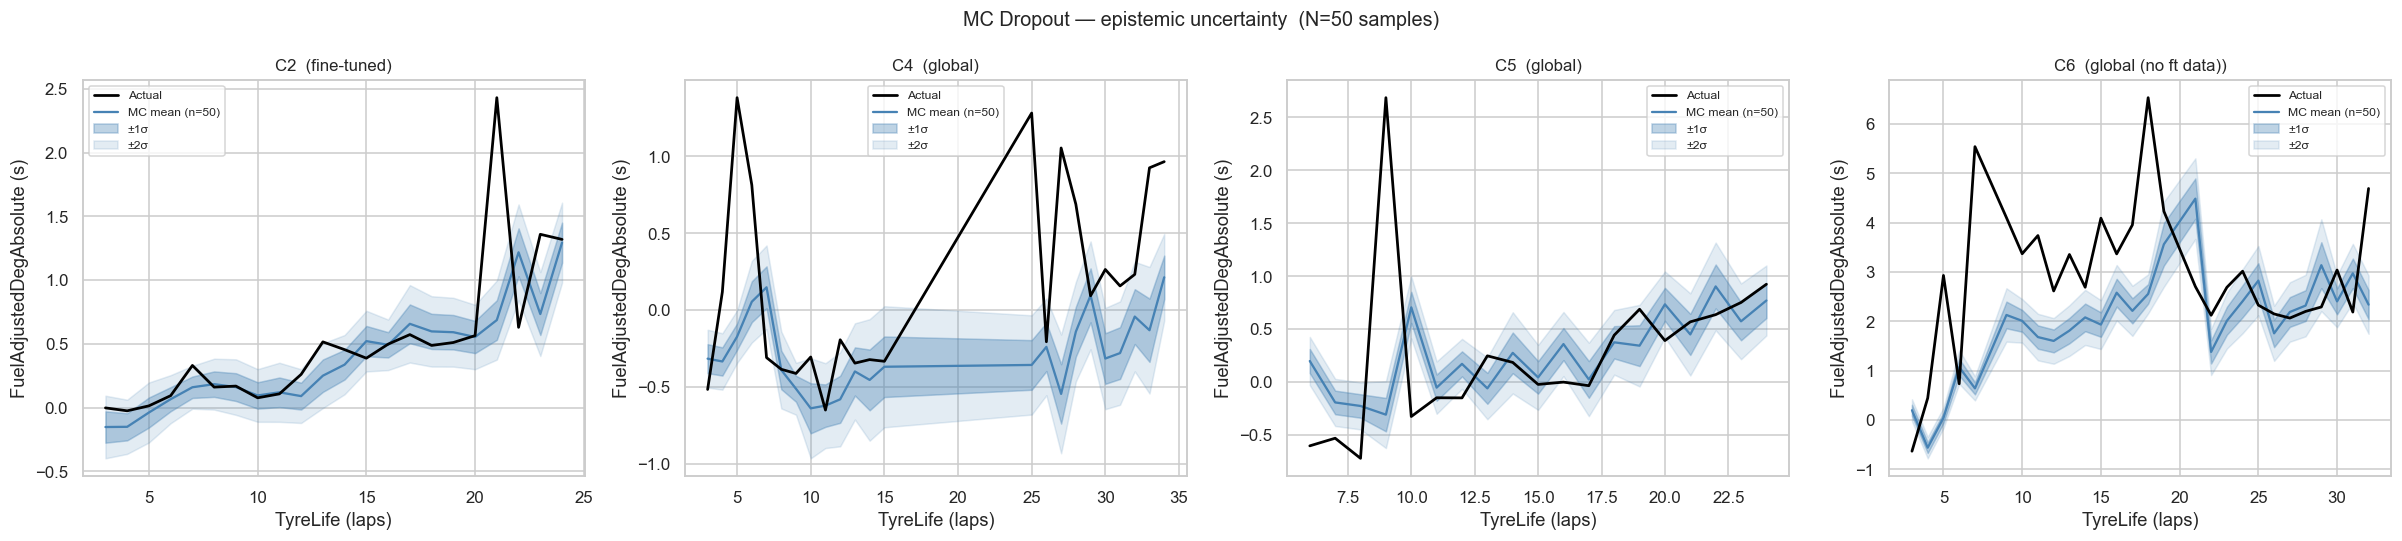

Mean sigma per compound:
  C2: mean sigma = 0.1244 s  |  max sigma = 0.1878 s
  C4: mean sigma = 0.1504 s  |  max sigma = 0.2057 s
  C5: mean sigma = 0.1549 s  |  max sigma = 0.2071 s
  C6: mean sigma = 0.2621 s  |  max sigma = 0.4654 s


In [52]:
# ── Step 16 — MC Dropout uncertainty quantification ──────────────────────
# Requires: Step 10.5 (loads ft_registry + lit_global_ref) and Step 11.1 (apply_scaler, _pad_or_truncate)
assert 'ft_registry'   in dir() or 'ft_registry'   in vars(), 'Run Step 10.5 first'
assert 'lit_global_ref' in dir() or 'lit_global_ref' in vars(), 'Run Step 10.5 first'
N_MC = 50

def predict_stint_mc(stint_df, model, scaler, window, features, n_samples=N_MC):
    """
    MC Dropout: keep dropout active, run n_samples forward passes.
    Uses the same _pad_or_truncate helper as predict_stint_steps so the
    mask is passed correctly to TireDegTCN.forward(x, mask).
    Returns (tyre_life[1:], actual[1:], mean_pred, std_pred).
    """
    s      = stint_df.sort_values('TyreLife').reset_index(drop=True)
    scaled = apply_scaler(s.copy(), scaler, features)
    X      = scaled[features].fillna(0).values
    y      = s[TARGET].values
    tl     = s['TyreLife'].values

    model.train()   # keep dropout active
    all_preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds = []
            for t in range(1, len(X)):
                seq, mask = _pad_or_truncate(X[:t], window)
                x_t = torch.from_numpy(seq).unsqueeze(0)
                m_t = torch.from_numpy(mask).unsqueeze(0)
                preds.append(model(x_t, m_t).squeeze().item())
            all_preds.append(preds)
    model.eval()

    arr = np.array(all_preds)   # (n_samples, n-1)
    return tl[1:], y[1:], arr.mean(0), arr.std(0)

# ── C2 / C4 / C5 / C6 comparison ─────────────────────────────────────────
# C6 uses the global model (no fine-tuned version: zero 2023/2024 training data)
COMPARE = {
    'C2': ft_registry['C2'],
    'C4': ft_registry['C4'],
    'C5': ft_registry['C5'],
    'C6': (lit_global_ref, global_scaler, global_window),
}
PREFERRED = {
    'C2': 'fine-tuned',
    'C4': 'global',
    'C5': 'global',
    'C6': 'global (no ft data)',
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
mc_stats  = {}

for ax, (compound, (lit_m, sc, win)) in zip(axes, COMPARE.items()):
    stint_df = pick_stint(compound)
    if stint_df is None:
        ax.set_title(f'{compound} — no 2025 stint found')
        continue

    tl, actual, mu, sigma = predict_stint_mc(
        stint_df, lit_m.model, sc, win, PRODUCTION_FEATURES
    )
    mc_stats[compound] = {
        'mean_sigma': float(sigma.mean()),
        'p95_sigma':  float(np.percentile(sigma, 95)),
        'max_sigma':  float(sigma.max()),
    }

    ax.plot(tl, actual, color='black',     lw=1.8, label='Actual',       zorder=3)
    ax.plot(tl, mu,     color='steelblue', lw=1.5, label=f'MC mean (n={N_MC})')
    ax.fill_between(tl, mu - sigma,   mu + sigma,   alpha=0.35, color='steelblue', label='±1σ')
    ax.fill_between(tl, mu - 2*sigma, mu + 2*sigma, alpha=0.15, color='steelblue', label='±2σ')
    ax.set_title(f'{compound}  ({PREFERRED[compound]})', fontsize=11)
    ax.set_xlabel('TyreLife (laps)')
    ax.set_ylabel('FuelAdjustedDegAbsolute (s)')
    ax.legend(fontsize=8)

plt.suptitle(f'MC Dropout — epistemic uncertainty  (N={N_MC} samples)', fontsize=13)
plt.tight_layout()
plt.savefig(outputs_path / 'mc_dropout_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean sigma per compound:')
for c, st in mc_stats.items():
    print(f'  {c}: mean sigma = {st["mean_sigma"]:.4f} s  |  max sigma = {st["max_sigma"]:.4f} s')

### Step 16 — Observations

- **C2**: narrow bands — enough clean training data for dropout masks to produce
  consistent outputs; the fine-tuned model is confident.
- **C4**: wider bands than C2 — SC-contaminated training data leaves the model with
  inconsistent internal representations across dropout masks.
- **C5**: very wide bands — ~347 training laps is too few for the TCN to converge to a
  stable solution; each dropout mask activates a noticeably different sub-network.
- **C6**: expected widest bands — C6 never appeared in the 2023/2024 training set
  (Pirelli introduced it in 2025 only). The global model is fully extrapolating to an
  unseen compound. High sigma here is not a model failure; it correctly signals that the
  model is operating outside its training distribution.

The uncertainty ordering (C2 < C4 < C5 ≈ C6) mirrors the MAE ordering from Step 8 and
independently confirms the routing decisions in Step 14: the compounds where the model
is most uncertain are exactly the ones where the global fallback is preferred.

**Production note:** `predict_stint_mc` is a drop-in replacement for `predict_stint_steps`
with a `uncertainty=True` toggle. In the inference layer it can be exposed as an optional
flag — the Strategy Agent requests uncertainty estimates only when reasoning about pit
windows near the boundary of the safe operating range.

In [53]:
# ── Step 16 — Export MC Dropout calibration JSON ─────────────────────────────────────
import json

assert mc_stats, "Run the MC Dropout cell first (Step 16)"

calib = {
    compound: {
        "mean_sigma_s": round(st["mean_sigma"], 4),
        "p95_sigma_s":  round(st["p95_sigma"],  4),
        "max_sigma_s":  round(st["max_sigma"],  4),
    }
    for compound, st in mc_stats.items()
}

calib_path = EXPORT_DIR / "mc_dropout_calibration.json"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
with open(calib_path, "w", encoding="utf-8") as f:
    json.dump(calib, f, indent=2)

print(f"Saved calibration -> {calib_path}")
print(json.dumps(calib, indent=2))

Saved calibration -> c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\tire_degradation\mc_dropout_calibration.json
{
  "C2": {
    "mean_sigma_s": 0.1244,
    "p95_sigma_s": 0.1643,
    "max_sigma_s": 0.1878
  },
  "C4": {
    "mean_sigma_s": 0.1504,
    "p95_sigma_s": 0.1974,
    "max_sigma_s": 0.2057
  },
  "C5": {
    "mean_sigma_s": 0.1549,
    "p95_sigma_s": 0.1953,
    "max_sigma_s": 0.2071
  },
  "C6": {
    "mean_sigma_s": 0.2621,
    "p95_sigma_s": 0.4233,
    "max_sigma_s": 0.4654
  }
}
